# Transfermarkt data cleaning part 2

### Introduction
This notebook is mainly about engineering new features and making final preparation of the Transfermarkt data.

### Feature engineering
The aim is to create features realted to: **player influence, match importance and team presure**.All of these feature will be extremely important for the models and their predictions and all of them require a very detail and strict preprocesing which includes almost all of the transfermarkt datasets.

### About the features:
#### Players influence:
The impact of the football players during the matches is one of the most important things which influences the outcomes of the matches and their possible predictions.In order to create such kind of features I should consider many different factors such as: minutes played, goals, assists, injuries etc.I will identify if a player is a **key player**, which would mean a player which is playing constantly and also a **star player** which refers to the team most effective and outstanding player!

##### Possible features to be created:
- missing_players_count
- missing_key_players_count
- missing_star_players_count
- missing_importance_sum - The sum of the missing players importance score
- missing_importance_ratio - The division of the missing players importance score with the total team squad importance
- missing_defenders
- missing_midfielders
- missing_forwards
- starting_goalkeeper_missing

The features are more or less self-explanatory. \
These are the ones which are comming to my mind at the moment but for sure there will be more.

#### Match importance:
The matches themselves are not equally important!And this is the thing which I want to capture and identify!In order to do so, I need to consider other competitions besides LaLiga and this is the reason why I have collected so many data about so many competitions and matches.Alongside with the competitions, there are also factors such as fighting for a title or to not be dropped out of the division which is a problem for the last three or four teams in the league!There also more things which should be taken into account but this will happen as the work progress!

I want to specify that the match importance is directly related to the team presure, so keep this in mind!

##### Possible features to be created:
### Match Importance
- distance_to_title - counted as points gathered
- distance_to_top4
- distance_to_relegation - The team to drop out of the **first division**(which is LaLiga) and to go into the **second**!
- title_race_flag - If the team is fighting for the title
- relegation_battle_flag - If the match is between teams which both are fighting for their places into the division
- europe_race_flag - If the team is participating in another european competition
- days_until_next_match
- next_match_priority - **The matches should be ranked by priority(e.g World Cup: 1; Champions League: 2; Copa Del Ray: 3; La Liga: 4)**
- important_match_ahead - this includes matches for more important competitions in which the specific teams is participating in!
- matches_last_14_days
- rotation_risk

> It is important to mention that all of these features will be calculated and processed at the moment of the matches and there will not be introduced any data leakage, especially for the players influence features.

### Preprocessing
Before creating the actual features I need to deal with the `appearances`, `player_injuries` and `lineups` datasets.Actually, from these datasets the main and most important information will be collected.

#### About the appearances dataset:
The dataset contains the appearances of all players of all clubs in all of the competitions.This is the dataset from which the player's importance scores will be calculated.This will happen by calculating different rolling stats such as goals, assists, minuted played etc. up until the dates of the matches.

#### About the player_injuries dataset:
The dataset contains data about the injuries of each player within the dataset.The injuries are represented with their **start date** and their **end data**, including the id of the player and the type of his injury!This dataset will be used to create player's availability features!This means that for each of the teams matches in LaLiga, there will be identified if the team's players(all of them, including: **substitutes, starters, injured, suspended**) have been available at the moment of the matches!

#### About the lineups dataset:
The lineup dataset is about the line ups of the different teams for the matches.The dataset contains info about each of the line ups players for each of the matches for each of the teams within the dataset.This dataset will be used exactly to check which playres were available and which not!This is the base of the features which will be created!

#### Initial data cleaning:
In order to create the wanted features I will first need to deal with the datasets(specified above) by reducing their data and getting only that which is related to the objects of the project(The LaLiga teams and playres) and also make some surface cleaning of the datasets if it is required!

### Getting started
I will start by exploring and cleaning the `appearances, lineups` and `player_injuries` datasets:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from football_betting_analysis.features.features_creation import \
    create_season_feature, calculate_rolling_metric, \
    calculate_ewma_average, create_team_squad
from football_betting_analysis.features.features_transformation import build_player_tenure

from football_betting_analysis.config import DATE_FORMAT, START_DATE, END_DATE, WINDOW, TRANSFERMARKT_DATA_INTERIM_PATH
from football_betting_analysis.data.data_cleaning import optimize_dataframe_memory, validate_and_cast_dataframe_dtypes

from football_betting_analysis.data.save_data_into_file import save_data

### Loading the data:
Lets load all of the data that we will be working to:

In [2]:
matches_interim_df = pd.read_parquet('../../data/interim/transfermarkt_data/interim_matches_v1.parquet')

In [3]:
competitions_df = pd.read_csv('../../data/raw/transfermarkt_data/competitions.csv')

In [4]:
appearances_df = pd.read_csv('../../data/raw/transfermarkt_data/appearances.csv')

In [5]:
lineups_df = pd.read_csv('../../data/raw/transfermarkt_data/game_lineups.csv')

C:\Users\Asus\AppData\Local\Temp\ipykernel_12864\1064156889.py:1: DtypeWarning: Columns (0: number) have mixed types. Specify dtype option on import or set low_memory=False.
  lineups_df = pd.read_csv('../../data/raw/transfermarkt_data/game_lineups.csv')


In [6]:
injuries_df = pd.read_csv('../../data/raw/transfermarkt_data/player_injuries.csv')

In [7]:
transfers_df = pd.read_csv('../../data/raw/transfermarkt_data/transfer_history.csv')

In [8]:
appearances_df.columns

Index(['appearance_id', 'game_id', 'player_id', 'player_club_id',
       'player_current_club_id', 'date', 'player_name', 'competition_id',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played'],
      dtype='str')

In [9]:
lineups_df.columns

Index(['game_lineups_id', 'date', 'game_id', 'player_id', 'club_id',
       'player_name', 'type', 'position', 'number', 'team_captain'],
      dtype='str')

In [10]:
injuries_df.columns

Index(['player_id', 'season_name', 'injury_reason', 'from_date', 'end_date',
       'days_missed', 'games_missed'],
      dtype='str')

In [11]:
transfers_df.columns

Index(['player_id', 'season_name', 'transfer_date', 'from_team_id',
       'from_team_name', 'to_team_id', 'to_team_name', 'transfer_type',
       'value_at_transfer', 'transfer_fee'],
      dtype='str')

In [12]:
appearances_df.shape, lineups_df.shape, injuries_df.shape, transfers_df.shape

((1885697, 13), (3049833, 10), (143195, 7), (1101440, 10))

Now as we can see the datasets are really big!So I think that the first think that should be done is to reduce their size by getting only the data which is related to the objects of the project.This would mean that I should remove all of the players which have not been part from the Spanish LaLiga between the seasons **2014/2015** and **2024/2025**!This will reduce the size of the dataset **significantly**!

> I want to specify that all of these datasets are about the `players`, their appearances in different matches, their injuries and also their availability in their teams matches lineups!Just to be more clear with what data we are dealing with!

### Reducing the size's of the datasets:
How we reduce the data will then determine how the features will be constructed and also how useful and accurate they will be at all!So this is something very important and should not be done without thinking of the possible **consequences**!For example one wrong approach would be to get only the data which is from the LaLiga as a competition(`competition_id == ES1`).If we do that we will lost more of the important information that we have about the players and their appearances(in Champions league or Copa Del Ray for example) and then this will directly affect the `player influence` features!So in order to not make such mistakes I have decided to go with the following approach: I will only take the id's of the La Liga teams, and then I will filter the data by ensuring that there will not be remained competitions other than LaLiga and the other European cups(Champions League, League Europe, Copa Del Ray etc.).This is the most rightful approach because if I choose to get the id's of the players which have been a part of any season in LaLiga, this will cause problems because this way:

I do not excude the fact that these players could also have been a part to another competition in the date range we have defined.For example, **Jude Belingam**, a current Real Madrid player, has been a part of **Dortmund** before going for Real Madrid which will lead to the occurance of German competitions appearances.However, we don't want that!**We want to keep only the matches(appearances) played while the player belongs to a La Liga club**!But why this is the right approach here?Because when calculating players importances and defining the influence of a certain player, we want to do that using only tha stats of the player from the team he is currently in(which is a team from LaLiga), without carring about any other teams or competitions that he has been playing in!We should ask: **How important is the player to his current team? not: How important was he three years ago in another league?**

Enough talking, lets begin by getting the id's of the LaLiga teams.I can do that using the cleabed `matches` dataset.But before doing so, I will first need to limit the date ranges of these datasets, so that we are working only with data from the seasons: **2014/2015 and 2024/2025**!

In [13]:
appearances_df['date'] = pd.to_datetime(appearances_df['date'], format=DATE_FORMAT)
lineups_df['date'] = pd.to_datetime(lineups_df['date'], format=DATE_FORMAT)
injuries_df['from_date'] = pd.to_datetime(injuries_df['from_date'], format=DATE_FORMAT)
injuries_df['end_date'] = pd.to_datetime(injuries_df['end_date'], format=DATE_FORMAT)
transfers_df['transfer_date'] = pd.to_datetime(transfers_df['transfer_date'], format=DATE_FORMAT)

In [14]:
appearances_interim_df = appearances_df[
    (appearances_df.date >= START_DATE) &
    (appearances_df.date <= END_DATE)
]

In [15]:
lineups_interim_df = lineups_df[
    (lineups_df.date >= START_DATE) &
    (lineups_df.date <= END_DATE)
]

In [16]:
injuries_interim_df = injuries_df[
    (injuries_df.from_date.between(START_DATE, END_DATE)) &
    (injuries_df.end_date.between(START_DATE, END_DATE))
]

In [17]:
transfers_interim_df = transfers_df.copy()

I will now reduce this dataset into the predefined data range, because later this can cause problems and important info can be removed! 

In [18]:
appearances_interim_df.shape, lineups_interim_df.shape, injuries_interim_df.shape, transfers_interim_df.shape

((1472397, 13), (2519518, 10), (118127, 7), (1101440, 10))

In [19]:
del appearances_df, lineups_df, injuries_df, transfers_df

Ok, now as we limited our data into the project's defined date range, now lets get the target teams id's:

In [20]:
target_clubs = set(
    matches_interim_df.loc[
        matches_interim_df["competition_id"] == "ES1",
        "home_club_id"
    ]
).union(
    set(
        matches_interim_df.loc[
            matches_interim_df["competition_id"] == "ES1",
            "away_club_id"
        ]
    )
)

#### Reducing the size of the appearances data:

I will filter the data using the target teams id's and the player_club_id feature:

In [21]:
appearances_interim_df = appearances_interim_df[
    appearances_interim_df["player_club_id"].isin(target_clubs)
]

In [22]:
appearances_interim_df.shape

(146708, 13)

Now as an proof that I have not taken only data from the **LaLiga** competition, but the data also contains the other very important european competitions, here are all of the competitions that **Vinícius Júnior** has been participated in!This is based on the transfermarkt data and the players **of course**!

In [23]:
appearances_interim_df[appearances_interim_df.player_id == 371998].competition_id.unique()

<ArrowStringArray>
['ES1', 'CDR', 'CL', 'KLUB', 'SUC', 'USC']
Length: 6, dtype: str

#### Reducing the size of the lineups data:

In [24]:
lineups_interim_df = lineups_interim_df[
    lineups_interim_df["club_id"].isin(target_clubs)
]

In [25]:
lineups_interim_df.shape

(204082, 10)

#### Reducing the size of the players injuries data:

Now this dataset does not have club identifier, so I will just get the unique players id's from the lineups dataset and use them to filter the injuries dataset.I will use the lineups because this dataset contain more players than the appearances dataset: 

In [26]:
len(appearances_interim_df.player_id.unique()), len(lineups_interim_df.player_id.unique())

(2361, 3606)

If I use the `appearances` dataset, I will miss some players.And of course we do not want that!

In [27]:
target_players = set(
    lineups_interim_df.player_id.unique()
)

In [28]:
injuries_interim_df = injuries_interim_df[
    injuries_interim_df["player_id"].isin(target_players)
]

In [29]:
injuries_interim_df.shape

(12362, 7)

### Transfers data:
The transfers dataset contains the Team Transfers of all players within the dataset.This dataset is actually very important because later it could be used or check if a certain player is a historical squad member of a team at a time of a certain match and eventually include this info in the creation of the features.

As a features the dataset contains:

In [30]:
transfers_interim_df.shape

(1101440, 10)

In [31]:
transfers_interim_df.columns

Index(['player_id', 'season_name', 'transfer_date', 'from_team_id',
       'from_team_name', 'to_team_id', 'to_team_name', 'transfer_type',
       'value_at_transfer', 'transfer_fee'],
      dtype='str')

In [32]:
transfers_interim_df.dtypes

player_id                     int64
season_name                     str
transfer_date        datetime64[us]
from_team_id                  int64
from_team_name                  str
to_team_id                    int64
to_team_name                    str
transfer_type                   str
value_at_transfer             int64
transfer_fee                  int64
dtype: object

As we can see each row represents a transfer, the player that was transfered, the date of the transfer, the player's old and new clubs and the **trasnfer_fee** and also the player's value at the time of the transfer!Something which is very important to be specified is that even if a player is very expensive and his market price is very big, if at the time of the transfer, the player has been a **free agent**(which means that his contract with his last team has expired and he is without club), the new team is getting the player for free and therefore the **transfer_fee** will be **0**.However if the player has a contract with a certain team, the new team which wants the player must play a price established by the player's current team(and this price can really be anything, depending on the player and his importance for the team)!

However, now lets reduce the size of the dataset by leaving only the transfers of the players that we are interested in.For this purpose I will use the players id's of the `lineups_interim_df`, because this dataset contains a little bit more players that the `appearances_interim_df` dataset!

### Reducing the size of the Transfers dataset:

In [33]:
transfers_interim_df = transfers_interim_df[
    transfers_interim_df.player_id.isin(target_players)
]

In [34]:
transfers_interim_df.shape

(35424, 10)

##### I think that overall, this was what I could have done as a reduction and now it's time to observe the datasets and make some validations to ensure that everything is perfect:

#### Exploring and validating the datasets:

In [35]:
appearances_interim_df.info()

<class 'pandas.DataFrame'>
Index: 146708 entries, 265258 to 1736122
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   appearance_id           146708 non-null  str           
 1   game_id                 146708 non-null  int64         
 2   player_id               146708 non-null  int64         
 3   player_club_id          146708 non-null  int64         
 4   player_current_club_id  146708 non-null  int64         
 5   date                    146708 non-null  datetime64[us]
 6   player_name             146708 non-null  str           
 7   competition_id          146708 non-null  str           
 8   yellow_cards            146708 non-null  int64         
 9   red_cards               146708 non-null  int64         
 10  goals                   146708 non-null  int64         
 11  assists                 146708 non-null  int64         
 12  minutes_played          146708 non-null 

In [36]:
lineups_interim_df.info()

<class 'pandas.DataFrame'>
Index: 204082 entries, 256141 to 2774510
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   game_lineups_id  204082 non-null  str           
 1   date             204082 non-null  datetime64[us]
 2   game_id          204082 non-null  int64         
 3   player_id        204082 non-null  int64         
 4   club_id          204082 non-null  int64         
 5   player_name      204082 non-null  str           
 6   type             204082 non-null  str           
 7   position         204082 non-null  str           
 8   number           204082 non-null  object        
 9   team_captain     204082 non-null  int64         
dtypes: datetime64[us](1), int64(4), object(1), str(4)
memory usage: 31.0+ MB


In [37]:
injuries_interim_df.info()

<class 'pandas.DataFrame'>
Index: 12362 entries, 47 to 143188
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   player_id      12362 non-null  int64         
 1   season_name    12362 non-null  str           
 2   injury_reason  12362 non-null  str           
 3   from_date      12362 non-null  datetime64[us]
 4   end_date       12362 non-null  datetime64[us]
 5   days_missed    12362 non-null  float64       
 6   games_missed   12362 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(2), str(2)
memory usage: 999.2 KB


In [38]:
transfers_interim_df.info()

<class 'pandas.DataFrame'>
Index: 35424 entries, 159 to 1101302
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   player_id          35424 non-null  int64         
 1   season_name        35424 non-null  str           
 2   transfer_date      35420 non-null  datetime64[us]
 3   from_team_id       35424 non-null  int64         
 4   from_team_name     35424 non-null  str           
 5   to_team_id         35424 non-null  int64         
 6   to_team_name       35424 non-null  str           
 7   transfer_type      35424 non-null  str           
 8   value_at_transfer  35424 non-null  int64         
 9   transfer_fee       35424 non-null  int64         
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 4.2 MB


The only missing values which I can see are in the `Transfers` transfer_date column and there are 4 missing values.I think that this is acceptable and will not be a very big problem.Anyway, all of the other dataset seems to be absolutely perfect!

Now as a minimum cleaning I will lower-cast their data types and optimize the datasets memory usage:
### Fixing the data types:

In [39]:
appearances_interim_df = validate_and_cast_dataframe_dtypes(appearances_interim_df)
lineups_interim_df = validate_and_cast_dataframe_dtypes(lineups_interim_df)
injuries_interim_df = validate_and_cast_dataframe_dtypes(injuries_interim_df)

The Transfers data does not need any data type casting as all of its features are with valid data types!

### Optimizing the datasets memory usage:

In [40]:
appearances_interim_df = optimize_dataframe_memory(appearances_interim_df)
lineups_interim_df = optimize_dataframe_memory(lineups_interim_df)
injuries_interim_df = optimize_dataframe_memory(injuries_interim_df)
transfers_interim_df = optimize_dataframe_memory(transfers_interim_df)

Initial Memory Usage: 19.87 MB
Final Memory Usage: 8.55 MB
Memory Reduction: 56.96%

Optimized Data Types:
appearance_id                        str
game_id                            int32
player_id                          int32
player_club_id                     int16
player_current_club_id             int32
date                      datetime64[us]
player_name                     category
competition_id                  category
yellow_cards                        int8
red_cards                           int8
goals                               int8
assists                             int8
minutes_played                     int16
dtype: object
Initial Memory Usage: 39.32 MB
Final Memory Usage: 14.12 MB
Memory Reduction: 64.10%

Optimized Data Types:
game_lineups_id               str
date               datetime64[us]
game_id                     int32
player_id                   int32
club_id                     int16
player_name              category
type                     category


Now I want to make some validations:

#### Only valid competitions: 
First, are there any other competitions than the: 
**Spanish specific**:
- LaLiga
- Copa Del Ray
- Supercopa

**Europe specific**:
- Champions League
- Europe League
- Conference League
- UEFA Super Cup - which is played between the winners of the Champions league and the Europe League

**World wide(FIFA)**:
- World Cup
- European cup

In [41]:
target_competitions = appearances_interim_df.competition_id.unique()

In [42]:
competitions_df[competitions_df.competition_id.isin(target_competitions)]

,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,total_clubs,url
9,CDR,copa-del-rey,copa-del-rey,domestic_cup,domestic_cup,157,Spain,ES1,europa,20.0,https://www.transfermarkt.co.uk/copa-del-rey/s...
12,CL,uefa-champions-league,uefa-champions-league,uefa_champions_league,international_cup,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-champions...
13,CLQ,uefa-champions-league-qualifying,uefa-champions-league-qualifying,uefa_champions_league_qualifying,international_cup,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-champions...
20,ECLQ,uefa-conference-league-qualifiers,uefa-conference-league-qualifiers,uefa_conference_league_qualifiers,other,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-conferenc...
21,EL,uefa-europa-league,uefa-europa-league,uefa_europa_league,other,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-europa-le...
22,ELQ,uefa-europa-league-qualifying,uefa-europa-league-qualifying,uefa_europa_league_qualifying,other,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-europa-le...
23,ES1,laliga,laliga,first_tier,domestic_league,157,Spain,ES1,europa,20.0,https://www.transfermarkt.co.uk/laliga/startse...
35,KLUB,fifa-klub-wm,fifa-klub-wm,fifa_club_world_cup,other,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/fifa-klub-wm/s...
59,SUC,supercopa,supercopa,domestic_super_cup,other,157,Spain,ES1,europa,20.0,https://www.transfermarkt.co.uk/supercopa/star...
66,USC,uefa-super-cup,uefa-super-cup,uefa_super_cup,international_cup,-1,NaN,NaN,europa,NaN,https://www.transfermarkt.co.uk/uefa-super-cup...


Well from what I can see everything seems to be perfect!

#### 
Now lets ensure that the data is within the project defined date range: 2014/2015 - 2024/2025:

In [43]:
appearances_interim_df.date.dt.year.unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025], dtype=int32)

In [44]:
lineups_interim_df.date.dt.year.unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025], dtype=int32)

In [45]:
injuries_interim_df.season_name.unique().tolist()

['24/25',
 '23/24',
 '20/21',
 '19/20',
 '18/19',
 '17/18',
 '22/23',
 '21/22',
 '15/16',
 '16/17',
 '14/15',
 '13/14']

Ok the dates seems to be fine.

Lets check if there is an player injury with end date smaller than or equal to the start date!

In [46]:
injuries_interim_df[
    injuries_interim_df.end_date <= injuries_interim_df.from_date
].shape

(46, 7)

In [47]:
injuries_interim_df[
    injuries_interim_df.end_date == injuries_interim_df.from_date
].shape

(46, 7)

Ok there are not invaid dates such as with end date before start date, but there are one day injuries.Actually these injuries are totally valid acceptable.However, what I am more intereset in, is the fact that there are injuries which have not affected the player's matches, **which means even that certain player has been injured, he has not missed any matches**!

By the way, lets see how many are these players:

In [48]:
injuries_interim_df[injuries_interim_df.games_missed == 0].shape

(537, 7)

There are not very much but still there are some!The question is: Are these injuries useful for the features that we want to create or not?Should I remove them?Well if we look at the feature we want to create:
- missing_players_count
- missing_key_players_count
- missing_star_players_count
- missing_importance_sum - The sum of the missing players importance score
- missing_importance_ratio - The division of the missing players importance score with the total team squad importance
- missing_defenders
- missing_midfielders
- missing_forwards
- starting_goalkeeper_missing

As we can see they are all related to counts.And in order, these counts to mean something, they should be generated only from injuries that actually made players unavailable for matches.So I think that the most right thing think would to be remove these useless injuries!

### Removing useless injuries:

In [49]:
injuries_interim_df = injuries_interim_df[injuries_interim_df.games_missed > 0]

In [50]:
injuries_interim_df[injuries_interim_df.games_missed == 0]

,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed


### Chacking for duplicates:

I want to ensure that there are not any duplicates within the data, so as duplicates criteria I will define:

Player appearance: **game_id, player_id** \
Lineup: **game_id, player_id** \
Player injury: **player_id, from_date**

So lets check:

In [51]:
appearances_interim_df.duplicated(
    subset=[
        'game_id', 'player_id'
    ]
).any()

np.False_

In [52]:
lineups_interim_df.duplicated(
    subset=[
        'game_id', 'player_id'
    ]
).any()

np.False_

In [53]:
injuries_dupes = injuries_interim_df.duplicated(
    subset=[
        'player_id', 'from_date'
    ],
    keep=False
)

injuries_dupes[injuries_dupes == True].any()

np.True_

In [54]:
injuries_interim_df[injuries_dupes].sort_values(by=['player_id', 'from_date']).head(10)

,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
30240,19447,17/18,Muscle injury,2017-11-25,2017-12-10,16,4
30241,19447,17/18,bruise,2017-11-25,2017-12-04,10,3
35731,21369,18/19,Ankle ligament tear,2019-04-24,2019-05-25,32,5
35732,21369,18/19,Ankle ligament tear,2019-04-24,2019-05-25,32,5
55487,29401,20/21,Calf stiffness,2021-05-07,2021-05-19,13,3
55488,29401,20/21,Calf stiffness,2021-05-07,2021-05-19,13,3
70017,35534,17/18,muscular problems,2017-08-28,2017-09-02,6,1
70018,35534,17/18,muscular problems,2017-08-28,2017-08-31,4,1
83649,41541,20/21,Calf problems,2021-01-14,2021-02-15,33,7
83650,41541,20/21,Calf problems,2021-01-14,2021-02-11,29,6


Now as we can see there are duplicates into the dataset.Also there are exact duplicates which match entierly on each of the columns and there are some which are more specific and which will be the problematic ones!

What I will do is that I will first drop the exact duplicates and then I will think of a way to handle the rest more specific ones:

#### Dropping exact injuries duplicates:
What I have found out is that almost all of the duplicates(**player_id + date**) differ in different way.Some of them only differ in the type of injury.Others differ in the missed days, third in **games missed**.Here is the thing - I don't really care in what they differ as long as they share the same missed games value.Again I will say that for the features we want to create the most important factor is the actual amount of games which the player has missed because of the injury, so if there are duplicates which share the same amount of missed games, but differ in something else, this is not a problem!!!

So lets first drop the exact duplicates:

In [55]:
injuries_interim_df = injuries_interim_df.drop_duplicates()

Now look at the ones which are duplicates and do not differ in the games_missed column:

In [56]:
injuries_interim_df[injuries_interim_df.duplicated(
    subset=['player_id', 'season_name', 'from_date', 'games_missed'], keep=False)]

,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
18591,158863,20/21,Shoulder injury,2021-04-20,2021-04-24,5,1
18592,158863,20/21,Ill,2021-04-20,2021-04-22,3,1
29769,193098,21/22,Muscle injury,2022-01-17,2022-01-20,4,1
29770,193098,21/22,Muscle injury,2022-01-17,2022-01-19,3,1
45697,255755,23/24,Inguinal hernia,2023-12-01,2023-12-18,18,4
45698,255755,23/24,Muscle tear,2023-12-01,2023-12-18,18,4
52810,286384,23/24,Shoulder injury,2023-10-08,2023-10-29,22,3
52811,286384,23/24,Hamstring strain,2023-10-08,2023-10-29,22,3
58240,311287,17/18,Ankle injury,2017-09-26,2017-10-17,22,3
58241,311287,17/18,Ankle sprain,2017-09-26,2017-10-17,22,3


As we can see that these duplicates differ in the end date and in the days missed, but do not differ in the **games_missed** column, which is the most important.So what I will do is that I will first sort the injuries data by player_id and start date to pack the duplicates together and then **descending** by **days_missed**, so that I to take the ones with more days missed, as this is usually the most preferable approach!

#### Sorting the injuries dataset:

In [57]:
injuries_interim_df = injuries_interim_df.sort_values(
    by=['player_id', 'from_date', 'days_missed'], 
    ascending=[True, True, False]
)

Now lets drop the duplicates and leave the ones which are with more days missed:

In [58]:
injuries_interim_df = injuries_interim_df.drop_duplicates(
    subset=[
        'player_id', 'season_name', 'from_date', 'games_missed'
    ],
    keep='first'
)

And now, lastly we should deal with the duplicates which difer in the amount of missed games: 

In [59]:
injuries_interim_df[injuries_interim_df.duplicated(
    subset=[
        'player_id', 'from_date'
    ],
    keep=False
)]

,player_id,season_name,injury_reason,from_date,end_date,days_missed,games_missed
30240,19447,17/18,Muscle injury,2017-11-25,2017-12-10,16,4
30241,19447,17/18,bruise,2017-11-25,2017-12-04,10,3
83649,41541,20/21,Calf problems,2021-01-14,2021-02-15,33,7
83650,41541,20/21,Calf problems,2021-01-14,2021-02-11,29,6
3520,110366,23/24,Cruciate ligament injury,2023-04-17,2023-08-06,112,7
3521,110366,22/23,Meniscus injury,2023-04-17,2023-06-19,64,7
32227,199299,18/19,ankle sprain,2019-02-01,2019-02-22,22,5
32228,199299,18/19,ankle sprain,2019-02-01,2019-02-08,8,1
34029,205503,18/19,Muscle injury,2018-08-24,2018-09-03,11,3
34030,205503,18/19,Muscle injury,2018-08-24,2018-08-31,8,2


What I will do here is that I will again leave the injury which was the longer one.As I do not have enough information and cannot really state what was the case with these players I would say that the possible reason behind these injuries could be the fact that at first, when the player has injured himself, there could have been given a date(like a posible prediction of how long the player will be out), and then due to some circumstances, this date to have been changed!This is what I can think of not, and actually this is a very common and realistic situation in football!

Now lets fix the last remaining duplicates by just leaving the ones with the longer injury:

In [60]:
injuries_interim_df = injuries_interim_df.drop_duplicates(
    subset=[
        'player_id', 'from_date'
    ],
    keep='first'
)

Final validation:

In [61]:
injuries_interim_df.duplicated(
    subset=[
        'player_id', 'from_date'
    ],
    keep=False
).any()

np.False_

In [62]:
appearances_interim_df.shape, lineups_interim_df.shape, injuries_interim_df.shape

((146708, 13), (204082, 10), (11800, 7))

### Exploring the amount of actual matches contained in the datasets:
The appearances and lineups datasets are about playres and their matches.However, I want to see how many matches these datasets cover and are there any inconsistencies in them.This is very important because if these datasets have a lot of missed or inconsistent matches, this will be a very big problem when creating the features!

In order to so I will need to create another table which contains only the unique matches, which means only to drop all of duplicates with criteria: game_id and date.This will leave only one unique match for the date!

In [63]:
test_appearances_data = appearances_interim_df.copy()
test_appearances_data = test_appearances_data.drop_duplicates(subset=[
    'game_id', 'date'
], keep='first')

# Creating a season feature so that I can group by it and see how are the matches distributed across the seasons:
test_appearances_data['season'] = create_season_feature(test_appearances_data, 'date')

In [64]:
games_per_season = test_appearances_data.groupby('season')['game_id'].count().reset_index()
games_per_season.columns = ['season', 'number_of_games']

In [65]:
games_per_season

,season,number_of_games
0,2014/2015,516
1,2015/2016,536
2,2016/2017,525
3,2017/2018,529
4,2018/2019,529
5,2019/2020,512
6,2020/2021,539
7,2021/2022,528
8,2022/2023,514
9,2023/2024,517


Ok for the appearances data it seems that the matches are overall well distributed.And I think that actually, what we see is very true and realistic because if we take the LaLiga matches which are **380** total per season and also add the matches from the other competitions(European cups, domestic cups etc) we will get something like that.

Now lets see the matches specifically from LaLiga:

In [66]:
laliga_games_per_season = test_appearances_data[
    test_appearances_data.competition_id == 'ES1'    
].groupby('season')['game_id'].count().reset_index()

laliga_games_per_season.columns = ['season', 'number_of_games']

In [67]:
laliga_games_per_season

,season,number_of_games
0,2014/2015,380
1,2015/2016,380
2,2016/2017,380
3,2017/2018,380
4,2018/2019,380
5,2019/2020,380
6,2020/2021,380
7,2021/2022,380
8,2022/2023,380
9,2023/2024,380


Ok here everything is perfect.

Now lets check the same thing with the lineups data:

In [68]:
test_lineups_data = lineups_interim_df.copy()
test_lineups_data = test_lineups_data.drop_duplicates(subset=[
    'game_id', 'date'
], keep='first')

test_lineups_data['season'] = create_season_feature(test_lineups_data, 'date')

In [69]:
games_per_season = test_lineups_data.groupby('season')['game_id'].count().reset_index()
games_per_season.columns = ['season', 'number_of_games']

In [70]:
games_per_season

,season,number_of_games
0,2014/2015,534
1,2015/2016,543
2,2016/2017,531
3,2017/2018,541
4,2018/2019,415
5,2019/2020,523
6,2020/2021,551
7,2021/2022,538
8,2022/2023,526
9,2023/2024,532


As we can see, again the matches are overall with realistic counts, but there are also many missing ones, especially in season **2018/2019** when we have **415** matches, which surely is not the right amount of total matches played!

Lets see the LaLiga matches:

In [71]:
target_games = test_appearances_data[test_appearances_data.competition_id == 'ES1'].game_id.values.tolist()

In [72]:
laliga_games_per_season = test_lineups_data[
    test_lineups_data.game_id.isin(target_games)
].groupby('season')['game_id'].count().reset_index()

laliga_games_per_season.columns = ['season', 'number_of_games']

In [73]:
laliga_games_per_season

,season,number_of_games
0,2014/2015,380
1,2015/2016,380
2,2016/2017,380
3,2017/2018,380
4,2018/2019,332
5,2019/2020,380
6,2020/2021,380
7,2021/2022,379
8,2022/2023,380
9,2023/2024,380


As I have expected, there are missing matches in season **2018/2019**, and there are 48 missing matches, which is not good!This would mean that for these matches certain players will be with unidentified starting info(did he start the match or he was a substitute).This is important info which we just cannot know at this moment with this data!However, I will keep this is mind and when we create the feature we should think what to do with these missing players!

In [74]:
del test_appearances_data, test_lineups_data

### Dealing with the Transfer data:
Now in order to use this data properly, I need to make a little reconstruction to the data.What I mean by this, is that I will transform this data into the following structure: **(player_id, club_id, joined_date, left_date)**!This will help me later, when I want to identify if a player has been a part from a certain team at the time of the matches!

Now before doing that lets explore what this data contains.
#### Types of transfers:

In [75]:
transfers_interim_df.transfer_type.value_counts()

transfer_type
Transfer            24385
Loan                 5521
Return from loan     5515
Draft                   3
Name: count, dtype: int64

In [76]:
transfers_interim_df.to_team_name.value_counts()

to_team_name
Without Club       1337
Retired             528
Granada CF          325
Atlético Madrid     306
Dep. La Coruña      298
                   ... 
Zuidvogels Yth.       1
Zulte U19             1
Órdenes               1
Čukarički U17         1
Čukarički U19         1
Name: count, Length: 3400, dtype: int64

We can see that there are many transfers have resulted in no new team for the playeres!This is normal! 

In [77]:
transfers_interim_df.from_team_name.value_counts()

from_team_name
Without Club       1024
Granada CF          307
Atlético Madrid     286
Real Valladolid     279
Dep. La Coruña      278
                   ... 
Árabe Unido II        1
Écija U19             1
Évreux Jugend         1
Čukarički U17         1
Čukarički U19         1
Name: count, Length: 3995, dtype: int64

And of course many of the transfers have been made while the players have been free agents(without club)!

In [78]:
transfers_interim_df[transfers_interim_df.to_team_id.isin([515, 123])].to_team_name.value_counts()

to_team_name
Without Club     1337
Retired           528
 Víkingur Ó.        0
1.FC Köln           0
1.FC Köln II        0
                 ... 
Órdenes             0
Újpest FC           0
Ümraniyespor        0
Čukarički U17       0
Čukarički U19       0
Name: count, Length: 3400, dtype: int64

We can see that there are transfers which shows the retirement of players!
All of this things should be taken into account when reconstructing the dataset and then identifying if a player has been at a certain club at a time of match!

---

However, the most important thing is that there are normal transfers and loan ones.The load transfer is done when a team loans a player to another team, but the team still owns the player.Many teams actually do that in order to not let their potentional players to lose their time not playing, but to go into another team and develop.As you can guess such players are important for their teams, but at the moment they might not so enough reliable and developed to give them time to play, so they take the opportunity to loan these players to other teams which will give them this time and eventually at some moment these players will return to their original teams better and ready to play!

This is something which we should strongly consider when identifing if a player is at a certain team at the moment of the matches, because he can be loaned at this time for example!

However, lets make some validations:
#### Checking for duplicates:

In [79]:
dupes = transfers_interim_df.duplicated(
    subset=[
        'player_id', 'transfer_date'
    ],
    keep=False
)

dupes[dupes == True].any()

np.True_

In [80]:
len(dupes[dupes == True])

54

In [81]:
transfers_interim_df[dupes].sort_values(by=['player_id', 'transfer_date']).head(10)

,player_id,season_name,transfer_date,from_team_id,from_team_name,to_team_id,to_team_name,transfer_type,value_at_transfer,transfer_fee
578557,3979,97/98,1997-07-01,13711,Real Madrid U17,39822,Real Madrid U18,Transfer,0,0
578558,3979,97/98,1997-07-01,39822,Real Madrid U18,28870,Real Madrid U19,Transfer,0,0
977228,7945,99/00,1999-07-01,28870,Real Madrid U19,2868,Real Madrid C,Transfer,0,0
977229,7945,99/00,1999-07-01,2868,Real Madrid C,6767,Real Madrid B,Transfer,0,0
198627,16635,03/04,2003-07-01,28870,Real Madrid U19,6767,Real Madrid B,Transfer,0,0
198628,16635,03/04,2003-07-01,6767,Real Madrid B,418,Real Madrid,Transfer,0,0
357602,25462,23/24,2023-07-01,82571,UD Caravaca,123,Retired,Transfer,0,0
357603,25462,23/24,2023-07-01,82571,UD Caravaca,68689,EDMF Churra,Transfer,0,0
635518,44675,05/06,2005-07-01,70295,Barça Youth,14321,Barça U16,Transfer,0,0
635519,44675,05/06,2005-07-01,14321,Barça U16,2470,Barça U19,Transfer,0,0


Ok as we can see, again there are different types of duplicates.There are the exact ones which will be fixed easly, but also there are multi staged transfers(more than one transfer happened in one day with more than two clubs participating in these transfers).For example there are cases when a player has changed two teams in a period of one day.In fact, such scenarios are absolutely valid in football.

Here are the possible cases that could have caused these duplicates:
1. **Re-sign and immediate lease (Buy-and-Loan)**
    - This is the most common case in modern football. A big club buys the rights to a player from a smaller team and on the same day (usually in the final hours of the transfer window) hands him over on loan. Often the player is loaned back to the same team from which he was bought to finish the season, or is sent to a satellite club.Example in the registers: Within a few hours, a player moves from Team A to Team B (permanent transfer) and immediately afterwards from Team B to Team C (loan).

2. **Triggering a buyback clause and subsequent sale**
    - Sometimes a club (Team B) has a buyout clause for a player who was on loan to them or whose rights were shared. If another larger club (Team C) shows interest, Team B triggers its clause in the morning, buys the player from Team A, and sells him to Team C in the afternoon for a quick financial gain.

3. **Administrative termination of lease and new transfer**
    - If a player is on loan at Team B, but his parent club (Team A) receives a good offer for a permanent sale from Team C, two steps occur within the day:The lease with Team B is terminated early (the player returns to Team A).Team A immediately finalizes his sale to Team B.

So considering these situations, I am going to remove only the exact duplicates in the dataset and also the ones which do not have any logical relations between the first transfer and the second one(For example in the first transfer the player has moved from Barcelona to Real Madid and then in the same date he has moved from Atletico Madrid to Barcelona - there is not logic in that).So lets first remove the exact dupliactes!
#### Removing exact duplicates from the Transfers dataset:

In [82]:
transfers_interim_df = transfers_interim_df.drop_duplicates()

Now lets check if there are any other invalid or inlogical dulicates.I wil get all of the dupes by player_id and transfer date and check if there is a case different from the ones which we have considered as valid:

In [83]:
transfers_dupes = transfers_interim_df[
    transfers_interim_df.duplicated(
        subset=['player_id', 'transfer_date'],
        keep=False)
].sort_values(by=['player_id', 'transfer_date'])

Ok there are three players which I have noticed and it seems that their transfers are just unlogical and invalid.

Here they are:

In [84]:
transfers_dupes[transfers_dupes.player_id == 25462]

,player_id,season_name,transfer_date,from_team_id,from_team_name,to_team_id,to_team_name,transfer_type,value_at_transfer,transfer_fee
357602,25462,23/24,2023-07-01,82571,UD Caravaca,123,Retired,Transfer,0,0
357603,25462,23/24,2023-07-01,82571,UD Caravaca,68689,EDMF Churra,Transfer,0,0


On 2023-07-01 the player leaves UD Caravaca. According to the first record he retires (Retired) and according to second he moves to EDMF Churra - absolutely unlogical!I will remove this player transfer!

The second one:

In [85]:
transfers_dupes[transfers_dupes.player_id == 396341]

,player_id,season_name,transfer_date,from_team_id,from_team_name,to_team_id,to_team_name,transfer_type,value_at_transfer,transfer_fee
575636,396341,23/24,2023-07-01,77079,UD Montijo,515,Without Club,Transfer,0,0
575637,396341,23/24,2023-07-01,21122,CD Móstoles,515,Without Club,Transfer,0,0


n 2023-07-01 the player goes into "Without Club" status . According to the first record he comes from UD Montijo , and according to the second record he comes from CD Móstoles - Again absolutely unlogical and invalid.This transfer will also be removed!

And here's the third final one:

In [86]:
transfers_dupes[transfers_dupes.player_id == 1064471]

,player_id,season_name,transfer_date,from_team_id,from_team_name,to_team_id,to_team_name,transfer_type,value_at_transfer,transfer_fee
31751,1064471,24/25,2025-01-01,8733,Celta Fortuna,940,Celta de Vigo,Transfer,400000,0
31752,1064471,21/22,2025-01-01,40419,Celta Vigo Yth.,15509,Celta U19,Transfer,400000,0


In the first record the player goes from Celta Fortuna -> Celta de Vigo. In the second record he goes from Celta Vigo Yth. -> Celta U19?I just don't find the logig, so this transfer will also be removed.

#### Removing invalid player's transfers:

In [87]:
indices_to_drop = [31751, 31752, 575636, 575637, 357602, 357603]
transfers_interim_df = transfers_interim_df.drop(indices_to_drop)

In [88]:
transfers_interim_df.shape

(35416, 10)

All of the other duplicates were absolutely valid and all of them fall into at least one of the possible valid cases we discussed!

**Enough with the explortion**, lets transform the dataset into the way that I have described in the begining: (player_id, team_id, joined_date, left_date)

### Reconstructuring the Transfers dataset
The transfers table should be processed into a precise tenure table with structure:
- `[player_id | club_id | joined_date | left_date | tenure_type]`

##### What the different transfers types mean: 
**"Transfer" / "Draft"** - permanent move; standard arrived/left window \
**"Loan"** - temporary window at the LOAN club only; parent club tenure is INTERRUPTED (player excluded from parent squad during loan period) \
**"Return from loan"**- closes the loan window at the loan club; re-opens / continues tenure at the parent club

##### How the more specific transfers scenarios will be handled:
These will beexcluded from valid squad membership: \
**"Without Club"** - (club_id = 515) \
**"Retired"** - (club_id = 123) \
**"Unknown"** - (club_id =  75)

I will define these clubs as **PHANTOM** clubs! \
Transfers to these clubs are used only to close the previous tenure window.

##### The goal
The goal is to produce a table of the form: **[player_id | club_id | joined_date | left_date | tenure_type]**
where each row represents one continuous period a player was registered to a specific club and was physically present (not on loan elsewhere).

##### Process of work:

1) **Clean the raw transfers table**:
    - Normalise **transfer_type** into canonical categories
    - Remove rows that go to phantom clubs from the "arrivals" side
        (they are still useful as departure signals on the "from" side)

2) **Build a per-player chronological event timeline**:
    - Each event has: date, from_team_id, to_team_id, event_type, sorted by (player_id, transfer_date).

3) **Walk the timeline per player and emit tenure windows**:
    - PERMANENT / DRAFT arrival at Club X:
        - Ppens a new tenure window at Club X
        - Closes any previously open window (player left that club)

    - LOAN to Club B (player currently at Club A):
        - SUSPENDS the tenure at Club A (insert a gap / set left_date)
        - Opens a LOAN tenure window at Club B

    - RETURN FROM LOAN back to Club A:
        - Closes the LOAN tenure window at the loan club
        - RE-OPENS tenure at Club A from this date (new row, same club)

    - Transfer TO a phantom club (retirement, without club, unknown):
        - Closes the current tenure; no new tenure opened

4) **The last open window per player has left_date = NaT**
    - Because there are no more transfers of that player and he is at his permanent parent club!

As I have explained the process lets begin:

In [89]:
transfers_interim_df.columns

Index(['player_id', 'season_name', 'transfer_date', 'from_team_id',
       'from_team_name', 'to_team_id', 'to_team_name', 'transfer_type',
       'value_at_transfer', 'transfer_fee'],
      dtype='str')

In [90]:
transfers_clean = (
    transfers_interim_df[[
        "player_id", "transfer_date",
        "from_team_id", "to_team_id",
        "transfer_type", "value_at_transfer",
        "transfer_fee"
    ]]
    .dropna(subset=["player_id", "transfer_date"])
    .drop_duplicates()
    .copy()
)

In [91]:
transfers_clean.shape

(35412, 7)

In [92]:
transfers_clean["transfer_type"] = (
    transfers_clean["transfer_type"]
    .fillna("Transfer")
    .str.strip()
    .str.title() # "transfer" -> "Transfer", "return from loan" -> "Return From Loan"
)

Now lets create a mapper which will map the type of the transfer to an internal canonical type:

In [93]:
TYPE_MAP = {
    "Transfer": "permanent",
    "Draft": "permanent",
    "Loan": "loan",
    "Return From Loan": "return_from_loan",
}

In [94]:
transfers_clean["event_type"] = transfers_clean["transfer_type"].map(TYPE_MAP).fillna("permanent")
 
transfers_clean = transfers_clean.sort_values(
    ["player_id", "transfer_date", "event_type"]
).reset_index(drop=True)

Now, as we have the event types of the transfers we are ready to transform the dataset into the form: **[club_id, joined_date, left_date, tenure_type]**.

For this transformations I have implemented the `build_player_tenure` function at [features_transformations.py](../../src/football_betting_analysis/features/features_transformation.py).

The function does exactly what I have described a little bit above in the notebook.It is moving between the different transfer windows of a player, checks what is the type of the transfer(whether it is normal transfer, loan, return from loan) and based on the transfer type it changes the states of previous trasfer windows of the players and adds new ones!

For more details see the function! \
Now lets apply the function to the dataset and transform it.

I forgot to say that the function requires a list of **phantom clubs ids** which are predifined indices of these teams: **Without Team, Unknown and Retired** - As you can quess these are not normal, valid team names, so they need to be handled more specifically!These ids were identified in the dataset exploration a little bit above in the notebool.So lets create this list: 

In [95]:
PHANTOM_CLUB_IDS = {515, 123, 75} # Without Club, Retired, Unknown

In [96]:
all_tenure_rows = []
 
for player_id, player_df in transfers_clean.groupby("player_id"):
    player_df = player_df.sort_values("transfer_date").reset_index(drop=True)
    windows = build_player_tenure(player_df, PHANTOM_CLUB_IDS)
    for w in windows:
        w["player_id"] = player_id
        all_tenure_rows.append(w)

Now lets pack the results into a data frame:

In [97]:
len(all_tenure_rows)

33500

In [98]:
tenure_table = pd.DataFrame(all_tenure_rows, columns=[
    "player_id", "club_id", "joined_date", "left_date", "tenure_type"
])

In [99]:
tenure_table = optimize_dataframe_memory(tenure_table)

Initial Memory Usage: 1.54 MB
Final Memory Usage: 0.80 MB
Memory Reduction: 48.10%

Optimized Data Types:
player_id               int32
club_id                 int32
joined_date    datetime64[us]
left_date      datetime64[us]
tenure_type          category
dtype: object


Now lets remove any windows that accidentally target phantom clubs:

In [100]:
tenure_table = tenure_table[
    ~tenure_table["club_id"].isin(PHANTOM_CLUB_IDS)
].reset_index(drop=True)

In [101]:
tenure_table.columns

Index(['player_id', 'club_id', 'joined_date', 'left_date', 'tenure_type'], dtype='str')

This was the transformation of the players transfers dataset!

#### With this I think that we have cleaned and explored all of the datasets, removed any duplicates and invalid records and applied the needed transformations!

### This was the cleaning and the exploration part of this notebook.Now lets proceed with the most important work:

---

## Feature Engineering:
Lets start with the creation of the `player influence, match importance and team presure` features.

As these three features are different and require different processing, I will seperate the work and start with the creation of the player influence features.One big factor in the player influence features is exactly the players availability in the matches and this is the reason why I have spended so much time in cleaning and preperation!

#### Player importance and the time factor in the football matches:
The most important question we should aks is: What defines a player influence and his importance during the matches?Something more, in what way this importance will be collected and what should be the time period in which the features will be created?

On the question what defines the player influence, there are really many factors which should be considered.For example how much time he has played throughout the matches and more importantly, what was his contribution for the teams in these matches!By contribution I many things like goals, assists and even team strength without the player!We should consider the how the team is working without the availability of a certain player.**The answers of these questions define the importance of a player and his influence for the matches!**

Now, something else we should think about: The football matches as the main data of out project and their outcomes as the target variable which we want to predict, **highly depend on the time as a factor!**.Why?In order to create a model which can really capture the underlying trends and features which influence the matches, we should consider **the time** as a factor from which we will create most of the features for the models.By using the time factor, we can create features such as **rolling averages** for example!By rolling averages I mean teams statistics like goals, assists, ball possesion, points gathered, etc., in a predefined **time window**!When we create such time-dependent features, we give, to our models, the oppotunity to observe the team's performance and their strenght at a bigger level!And we will think about this for a moment, actually, this is the only thing we can give to the predictive models as a useful info about the teams and their **likelihood** of winning the match.If we don't give this, we leave our models with very basic and static data from which nothing can be extracted!

The purpose of these explanations, is to emphasize the **importance** of the time in the features that we will creating and to say that in order to create really useful and meaningful features, we should not only use what we have at the moment of the matches, because most of the time it is nothing important, but to look at a bigger level and idenity the true, underlying factors which can define the outcomes of the matches!

#### Time as a Factor (Recency Weighting)
Time acts as a critical factor because **recent form** is much more relevant than form from two years ago. Many sports models account for this by utilizing an **Exponential Moving Average (EMA)**, which naturally gives heavier weight to a team's most recent matches and decays the impact of older games.**This is something really important and it should be considered when difining the time window in which the features will be created!**

Now lets start with the creation of the **historical player-strength** table.This will be the base from which the player importances will be defined!

#### Creating the historical player-strength table:
Before starting anything, we should define the Time Window as the date range from which the player importance features will be calculated.As I said, the **recent form**, of a player or a team at all, is much more important and relevant than a from really past form!And because of that I will define consider the last **10** games of the players from which their importance will be defined!As we will be working with the **appearances** data, 10 games refer to 10 appearances of a player or 10 games of that player!

In [102]:
WINDOW

10

#### Sorting the appearances table:

In [103]:
appearances_interim_df = appearances_interim_df.sort_values(
    ["player_id", "date"]
)

### Creating starter flags
One of the components which will define the player importance feature will be the time that the player has played during the matches or the start share which he has!It is important to identity if a player is a starter or a substitute!

We can see this using the players **lineups data**:

In [104]:
lineups_interim_df.type.value_counts()

type
starting_lineup    112973
substitutes         91109
Name: count, dtype: int64

In [105]:
lineups_interim_df['is_starter'] = (
    lineups_interim_df["type"]
    .str.lower()
    .str.contains("starting")
    .astype(int)
)

#### Creating player match starter table:
This table will contain the most important info that we should know about the players from their teams lineups!

In [106]:
starter_info = lineups_interim_df[
    [
        "game_id",
        "player_id",
        "club_id",
        "position",
        "team_captain",
        "is_starter"
    ]
].copy()

### Merging lineups with appearances
Now I will merge the created starter_info table with the appearances data:

In [107]:
player_matches = appearances_interim_df.merge(
    starter_info,
    on=["game_id", "player_id"],
    how="left"
)

In [108]:
player_matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 146708 entries, 0 to 146707
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   appearance_id           146708 non-null  str           
 1   game_id                 146708 non-null  int32         
 2   player_id               146708 non-null  int32         
 3   player_club_id          146708 non-null  int16         
 4   player_current_club_id  146708 non-null  int32         
 5   date                    146708 non-null  datetime64[us]
 6   player_name             146708 non-null  category      
 7   competition_id          146708 non-null  category      
 8   yellow_cards            146708 non-null  int8          
 9   red_cards               146708 non-null  int8          
 10  goals                   146708 non-null  int8          
 11  assists                 146708 non-null  int8          
 12  minutes_played          146708 non-null  

There are around 2 thousand missing values.As it seems, there are many players which vary across the two datasets(appearances and lineups)!Of course this is a cause from the thing we discovered in the exploration part, and it is that for season 2018/2019 there are around 150 missing games!And specifically for the LaLiga competition there are 48 missing games in that season!For sure, this is not the only problem which causes this big amount of missing players!

Lets observe what is happening:

In [109]:
missing_games = (
    player_matches.loc[
        player_matches["position"].isna(),
        "game_id"
    ]
    .unique()
)

len(missing_games)

119

In [110]:
missing_rows = player_matches[
    player_matches["position"].isna()
]

len(missing_rows)

2710

In [111]:
missing_rows["player_id"].nunique()

516

There are **119** missing games, **516** missing players and **2710** missing rows at all.

Now before making any hasty decisions, lets check how much these missing values affect the dataset:

In [112]:
affected_match_pct = (
    len(missing_games)
    /
    appearances_interim_df["game_id"].nunique()
)

affected_match_pct

0.020616770616770617

The affection seems to be quite small!One possible approach is to remove these missing games.And this would be the most professional way to handle this data, because if I do not remove them, I need to fill them up with some values - what values should I put for players which I just don't know!And these values should be about: have they started the match or not, their position etc.All of these values play a very big role into the player importance features and just to put some naive and unrealistic values would be very bad mistake!On top of that I have observed all of the datasets, their cleanings, filtering and everything else which could be related to these missing matches, and all of them lead to the single explanation - There are just missing matches in the Transfermarkt lineups dataset and that's it!!!

Now before removing the values lets check, if they are actually missing from the LaLiga competition or from the other(more unimportant) european competitions(Champtions league, League Europe, Copa Del Ray etc):

In [113]:
matches_interim_df[
    matches_interim_df["game_id"].isin(missing_games)
]["competition_id"].value_counts()

competition_id
CDR     68
ES1     49
CL       1
EL       1
CLQ      0
ECLQ     0
ELQ      0
EURO     0
FIWC     0
KLUB     0
SUC      0
UCOL     0
USC      0
Name: count, dtype: int64

Well, as we can see that most of them are from **Copa Del Ray**, but there is also a **significant** number from **LaLiga**.However, **not significant enough** to leave them into the dataset!We should really answer the question: What would be bad: to have these matches in the dataset, but with invalid values, or to not have them, but without invalid values which could make a bias to the model or something like that?I would go with the second approach!So lets remove these values?

#### Removing matches with missing data: 

In [114]:
bad_games = missing_rows["game_id"].unique()

Removing the invalid matches from the appearances dataset:

In [115]:
appearances_interim_df = appearances_interim_df[
    ~appearances_interim_df["game_id"].isin(bad_games)
]

Removing the invalid matches from the lineups dataset:

In [116]:
lineups_interim_df = lineups_interim_df[
    ~lineups_interim_df["game_id"].isin(bad_games)
]

In [117]:
appearances_interim_df.shape, lineups_interim_df.shape

((143970, 13), (204046, 11))

Merging again:

In [118]:
starter_info = lineups_interim_df[
    [
        "game_id",
        "player_id",
        "club_id",
        "position",
        "team_captain",
        "is_starter"
    ]
].copy()

In [119]:
player_matches = appearances_interim_df.merge(
    starter_info,
    on=["game_id", "player_id"],
    how="left"
)

In [120]:
player_matches.isna().any().any()

np.False_

In [121]:
player_matches.shape

(143970, 17)

As we can see, there are no longer missing values.However, what I will do is that I will save the id's of the invalid matches so that later I can preprocess them more detaily and eventually fix the problem!

In [122]:
bad_games_df = pd.DataFrame({
    "game_id": bad_games
})

In [123]:
PROJECT_ROOT = Path().resolve().parent.parent
INTERNAL_DATA_PATH = 'data/internal/'

file_path = PROJECT_ROOT / INTERNAL_DATA_PATH
file_path.mkdir(parents=True, exist_ok=True)

In [124]:
file_path = PROJECT_ROOT / INTERNAL_DATA_PATH / 'matches_without_lineups_info.csv'
try:
    bad_games_df.to_csv(file_path, index=False, mode='x')
except FileExistsError:
    print(f"File already exists at {file_path}. Skipping save.")

File already exists at C:\Users\Asus\Desktop\Data_Science\Football_Betting_Analysis\Football_Betting_Analysis\data\internal\matches_without_lineups_info.csv. Skipping save.


---

Now lets proceed with the creation of the features:

### Creating rolling players metrics:
Now it's time to create the rolling features from which the player importance score will be defined.In order to avoids leakage, I will shift by 1 match!

For the features I have implemented several functions which in different ways calculate the rolling metrics.The first and most standard one is the `calculate_rolling_metric`, which will create a **rolling metric** based on a provided function(e.g. sum, mean).I called this function the standard one, because it calculates the rolling features using a predefined time window(e.g 5, 10) and it takes all of the values up until that window and includes them into the calculations of the rolling feature.However, the thing is that this function gives equall weights to all of the values, without making difference between the more recent matches the more older ones!  

However, I have also implemented the `calculate_ewma_average` function which calculates *Exponentially Weighted Moving Average*.The purpose of this function is to give more account to the more recent matches by putting exponentially descresing weights to the more older matches.Something more, this function includes all of the past matches and it controls their weights using the **span** and adjust parameters.

The other function is the `calculate_time_based_ewma` function which in contrast to the `calculate_ewma_average` function, it calculates the rolling metric using the time-based EWMA instead of row-index EWMA.The functions allows you to pass a datetime index using the **times** parameter.As a result this will exponentially decays a player's form based on actual days passed, meaning their form naturally rusts over long periods of absence.So this function is actually very useful because it captures the player's absence and it rightfully accounts that their form might had have become weaker, as it is most of the times!

#### About the parameters **span** and **adjust**:
THese two paramteres are the essential driven factors of the ewma functions because from them depends how the values of the different data points contribute to the calculation of the rolling feature!

##### How they work mathematically:
The `span` controls the smoothing factor $(\alpha)$(alpha).The `calculate_ewma_average` function automatically calculates it using this exact formula:
$$
    \alpha = \frac{2}{span + 1}
$$
This means that if span is set to 5, alpha becomes $\frac{2}{6} = 0.33$. This means the very last match accounts for **33.3%** of the entire moving average value, while the remaining **66.7%** comes from all prior historical games combined.

The `adjust` parameter changes how pandas initializes the moving average when there is very little history (e.g., games 1, 2, and 3 of the season)
- adjust=False (Recursive Mode): It assumes the very first game is perfectly representative of the team's baseline ability. It initializes the calculation by setting the first average equal to the first game's score ($y_0 = x_0$)
- adjust=True (Weighted Average Mode): It treats the early games as limited samples. It dynamically scales down the importance of that first match so a single extreme blowout in Game 1 doesn't warp the team's metrics for the next 5 games

**Why I would use the adjust parameter set to False**:
- The data which we are working with is time series data which is grouped by seasons, so setting `adjust=False` allows the previous match's result to be recursively scaled with a weight of $\alpha$ without altering the starting values. It is highly useful in sports analytics for establishing a "prior" (like the team's average attacking strength) and iteratively updating it for each match as the season progresses!

The implementations of the functions: [features_creation](../../src/football_betting_analysis/features/features_creation.py)

Now I will start with the creation of the rolling minutes features.For this feature I will use the `calculate_ewma_average`, as I want give more account to the more recent matches!Firstly I will need to create a normalize the minutes into percantages so that after that the EWMA is directly operating on a normalized variable! 

In [125]:
player_matches["minutes_pct"] = (
    player_matches["minutes_played"] / 90
)

player_matches["minutes_share"] = calculate_ewma_average(
    data=player_matches,
    group_col="player_id",
    column="minutes_pct",
    span=5,
    adjust=False
)

Now lets calculate the **rolling starts** of the players.Again, I will use the `calculate_ewma_average` because starting status changes rapidly.Managers rotate.Transfers happen.Injuries happen.And because of that, I would put more weight on the more recent matches than giving the whole values equal weights!

In [126]:
player_matches["start_share"] = calculate_ewma_average(
    data=player_matches,
    group_col="player_id",
    column="is_starter",
    span=5,
    adjust=False
)

Now I will proceed with captain frequency feature which will define the consistency of a player to be the captain of the team, which of course will contribute a lot his importance in the matches and for the team at all!

First lets create a captain flag, which will indicate if the player has been the captain of the specific game and then I will create a captain frequency rolling average.This time I will use the `calculate_rolling_metric` function, as being a captain is overall a stable indicator, so it will be enough to see the player's captaincy in their previous 10 games!

In [127]:
player_matches["captain_flag"] = (
    player_matches["team_captain"]
    .fillna(False)
    .astype(int)
)

In [128]:
player_matches["captain_frequency"] = calculate_rolling_metric(
    data=player_matches,
    group_col='player_id',
    column='captain_flag',
    func='mean',
    window=WINDOW
)

Now lets proceed with the more important features.By important I mean the ones which can easily identify the player's influence in the matches.The **goals and assist**!For these two features I will use the `calculate_rolling_metric` function because for these specific features I much more interested to get the raw counts as goals for the players in the last 10 matches.Also after I create these features I will also need to create a `goals_per90` and `assists_per90` features which represent how the players perform within the game's 90 minutes interval - This is really important because if we want to capture the real influence of the players in the matches, we should make our calculations to be into the range of the matches themselves!

I will start with the **goals**:

In [129]:
player_matches["rolling_goals"] = calculate_rolling_metric(
    data=player_matches,
    group_col='player_id',
    column='goals',
    func='sum',
    window=WINDOW
)

Now the same for the **assists**:

In [130]:
player_matches["rolling_assists"] = calculate_rolling_metric(
    data=player_matches,
    group_col='player_id',
    column='assists',
    func='sum',
    window=WINDOW
)

Now before creating the `goals_per90 and assists_per90` features I will need to first create a rolling minutes feature in the range of the 10 last matches!Then I will use the **rolling minutes** to divide them from the rolling goals and assists and multiply the result by 90 to get the `goals_per90 and assists_per90` features!

In [131]:
player_matches["rolling_minutes"] = calculate_rolling_metric(
    data=player_matches,
    group_col='player_id',
    column='minutes_played',
    func='sum',
    window=WINDOW
)

And now I can create the per90 features:

In [132]:
player_matches["goals_per90"] = (
    player_matches["rolling_goals"]
    /
    player_matches["rolling_minutes"]
    * 90
)

player_matches["assists_per90"] = (
    player_matches["rolling_assists"]
    /
    player_matches["rolling_minutes"]
    * 90
)

Now with these two features(`goals_per90 and assists_per90`) I will define the players contribution score.And of course before doing that I'll need to fill any missing values of these two columns!

#### About the missing values:
With the creation of all these rolling features, the dataset currently has a lot of missing values and this because of the reason that for these rolling features to be created, there should be values before the current matches, and if there are not at least 1 value to take for the calculation(based on the **min_periods** param), the functions will return **NaN**.And as expected for the first matches of the players, there are no past values to take so all of the rolling features will be with NaN values.And in order for me to create some features I am required to fill this missing values with something.In the current situation the most logical value would be **0**! 

In [133]:
player_matches[
    ["goals_per90", "assists_per90"]
] = player_matches[
    ["goals_per90", "assists_per90"]
].fillna(0)

Now lets create the player's contribution score.

And of course I know that this **contribution score** will not be **relevant** to all of the different players in the dataset because they are with different positions and purposes at all.For example how would a contribution score defined from goals and assists will be relevant to a goalkeeper or to a defender?So for now I will just create the feature like that, and then when defining the **importance score** of the different players I will take into account the different types of players!

In [134]:
player_matches["contribution_score"] = (
    player_matches["goals_per90"]
    +
    0.7 * player_matches["assists_per90"]
)

the final list of features:

In [135]:
player_matches.columns

Index(['appearance_id', 'game_id', 'player_id', 'player_club_id',
       'player_current_club_id', 'date', 'player_name', 'competition_id',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played',
       'club_id', 'position', 'team_captain', 'is_starter', 'minutes_pct',
       'minutes_share', 'start_share', 'captain_flag', 'captain_frequency',
       'rolling_goals', 'rolling_assists', 'rolling_minutes', 'goals_per90',
       'assists_per90', 'contribution_score'],
      dtype='str')

### Now as the main features have been created, I should proceed by separating the players into their positional groups

This is extremely important, because each of the players has a different purpose in the matches and we can't lump them all together, because they are just different.And in order to create a reliable and realistic player's importance score, the separation of the players is just mandatory!

So first lets see what type of player's position do we have in the dataset:

In [136]:
player_matches.position.unique().tolist()

['Centre-Forward',
 'Centre-Back',
 'Left Midfield',
 'Attacking Midfield',
 'Left Winger',
 'Goalkeeper',
 'Second Striker',
 'Left-Back',
 'Central Midfield',
 'Defensive Midfield',
 'Right-Back',
 'Right Winger',
 'Right Midfield',
 'midfield',
 'Sweeper']

As we can see from the positions, we can distribute them into the following categories: 
- **Midfielders**: which refers to the playmakers in the game(The ones which play in the center of the pitch)
- **Defenders**: which refers to the defensive players which role is to stop the attackers of the opposite team
- **Attackers**: which refers to the top of the pitch and ofthen act as the star players, which scores goals and decide the matches!

If you don't understand the `Sweeper` position, it mainly refers to a specialized, deep-lying defensive player. Positioned just behind the main defensive line, the sweeper has no strict man-marking duties. Instead, they "sweep up" or mop up any loose balls, intercept through-balls, and serve as a final safety net!So yes it falls into the group of **Defenders**!

So I will create a function which will assign a group to each of the players by looking at their possitions:

In [137]:
def map_position(pos):
    pos = str(pos).lower()

    if any(x in pos for x in ['forward', 'winger', 'striker']):
        return "FWD"

    if any(x in pos for x in ['back', 'sweeper']):
        return "DEF"

    if any(x in pos for x in ['midfield']):
        return "MID"

    return "GK"

Now lets apply the function to the players:

In [138]:
player_matches["position_group"] = (
    player_matches["position"]
    .apply(map_position)
)

In [139]:
player_matches.position_group.value_counts(dropna=False)

position_group
DEF    46028
FWD    45792
MID    42208
GK      9942
Name: count, dtype: int64

The distribution of the different player's positions is actually very good, because this means that there is data for all types of players in the dataset!And of course the goalkeepers are less just because the goalkeepers of a team is moct of times only one player, and possibly two max if the first goalkeepers gets injured during a match!

Now before proceeding ahead, there is something very important that I have missed to do.Currenly the rolling fatures are scaled differently and this is because I have used different rolling function for their calculations.For the **minutes_share and start_share** I have used the `calculate_ewma_average` function which scales the data into a range of **[0 - 1]**.However, for the **captain_frequency and contribution_score** I have used the `calculate_rolling_metric` function which can produce values larger than 1.This will not be a very big problem when calculating the importance score, but still it is possible to get some strange results!So for this reason, I will need to normalize the contribution score feature so that it scales its values in the range between 0 and 1!The captain_frequency, actually, does not need to be scaled because it used the captain_flag which is a binary variable and then gets the mean from the values, which guarantees us that the values of this feature cannot exceed 1!

So lets make the normalization!
### Normalizing the cintribution score feature:
For the normalization, I will perform a bounded scaling using the `np.tanh` function which calculates the hyperbolic tangent of the values. It maps any real-valued number to a continuous output strictly between **[-1 - 1]**.However, the function will not produce any negative values, just because the contribution score as a feature does not contain values smaller than 0, so this means that the values will be in the range **[1 - 1]**

What I am trying to achive with this scalling is to not allow the contribution score to dominate the players importance score.And this will happen if I don't scale the feature because there are values larger than 1, up to 2 which can highly affect the importance score of the playres.So I should ensure that all of the features share one range of values!

In [140]:
player_matches["contribution_score_norm"] = np.tanh(
    player_matches["contribution_score"]
)

Now as everything is normalized, grouped and scaled correctly, lets created the player's importance score feature.For the importance score I will again create a function which based on the group of the player will apply different values to the different rolling features(that we have created) and this way it will form the player importance scores using all of the different components(the rolling features that we have created.Actually it will use only those which are relevant to the position group of the player - for example, into the importance score of the goalkeeper I will not include the **contribution_score** feature, **because a goalkeeper has nothing to do with goals and assists!**)

### Creating the importance score function:
Now the way that this function wil work, is that it will combine each of the features that we have created up until this moment(`minutes_share, start_share, captain_frequency, conyribution_score`) and for each of these features it will apply different weights based on the position of the player.So as I have already said, not all of the feature will be used into the calculations of their scores, because some of the features are not relevant to the positions and types of players.This will ensure that the scores of the playres and their importances will be cretaed, considering only the components and feature which are related to them!The weighs which are used in the function are created in way that mostly corresponds with the feature(with which the weight is used) and also the weights are created so that for the most important game components of the players, to have the strongets weights.So for example the weight of the contribution score feature for a striker will be much more bigger than the contribution score weight for the defenders!

In [141]:
def compute_importance(row):

    minutes_share = row["minutes_share"]
    start_share = row["start_share"]
    captain_frequency = row["captain_frequency"]
    contribution_score = row["contribution_score_norm"]

    p = row["position_group"]

    if p == "GK":
        return (
            0.60*minutes_share +
            0.30*start_share +
            0.10*captain_frequency
        )

    elif p == "DEF":
        return (
            0.50*minutes_share +
            0.35*start_share +
            0.15*captain_frequency
        )

    elif p == "MID":
        return (
            0.40*minutes_share +
            0.25*start_share +
            0.15*captain_frequency +
            0.20*contribution_score
        )

    else:
        return (
            0.40*minutes_share +
            0.25*start_share +
            0.10*captain_frequency +
            0.25*contribution_score
        )

Now lets finally apply the function:

In [142]:
player_matches["importance_raw"] = (
    player_matches
    .apply(compute_importance, axis=1)
)

In [143]:
player_matches.columns

Index(['appearance_id', 'game_id', 'player_id', 'player_club_id',
       'player_current_club_id', 'date', 'player_name', 'competition_id',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played',
       'club_id', 'position', 'team_captain', 'is_starter', 'minutes_pct',
       'minutes_share', 'start_share', 'captain_flag', 'captain_frequency',
       'rolling_goals', 'rolling_assists', 'rolling_minutes', 'goals_per90',
       'assists_per90', 'contribution_score', 'position_group',
       'contribution_score_norm', 'importance_raw'],
      dtype='str')

Ok now as the importance score feature has been created, we need to go even further by normalizing this feature into a **team relative strength**.What I mean by this is that I will create a **total team importance score**, by summing all of the players importance's scores!After I create the teams totals, I will create the final player importance score function as a result from the division between the player importance_raw(the initial player importance score feature that we created above) and the teams totals.This feature will really represent the player influence because the value of the feature will be calculated relative to the sum of all other player's importance scores!

First lets create the team totals:

In [144]:
team_totals = (
    player_matches
    .groupby(
        [
            "player_club_id",
            "date"
        ]
    )["importance_raw"]
    .transform("sum")
)

Now lets create the final player importance score feature, this time calculated relative to the team totals!

### Creating the final player importance score feature:

In [145]:
player_matches["importance_score"] = (
    player_matches["importance_raw"]
    /
    team_totals
)

In [146]:
player_matches["importance_score"] = (
    player_matches["importance_score"]
    .fillna(0)
)

Ok now as we have defined, **what a player importance score is**, its time to proceed with the creation of the other features.If you remember the introduction of the notebook, I have specified and explained some of the aim features that this notebook should create and here they are:
- missing_players_count
- missing_key_players_count
- missing_star_players_count
- missing_importance_sum - The sum of the missing players importance score
- missing_importance_ratio - The division of the missing players importance score with the total team squad importance
- missing_defenders
- missing_midfielders
- missing_forwards
- starting_goalkeeper_missing

As you can see, all of the features are about missing players.However, I will not consider the unavailability of a player the only factor which defines a player influence, so I can also create a feature about the available star players of a team or something like that.

Also something else you can see.In order for us to identify if a player is a star, key or whatever, first we should have had created the player importance score, with which now we can say if a player is key, star etc.So if you are following my point, I want to say that everything which we have created is for a reason and nothing is useless!

Now lets actually proceed with the creation of the rest features:
### Team ranking, key players, star players:
In order for me to categorize the contribution of the players,I will need to create a team ranking: 

In [147]:
player_matches["team_rank"] = (
    player_matches
    .groupby(
        [
            "player_club_id",
            "date"
        ]
    )["importance_score"]
    .rank(
        ascending=False,
        method="dense"
    )
)

The code above groups the players into team and matches dates, so that it can ranks them for their club and the specific match date.The **ascending=False** means that the highest score gets rank 1, the second-highest gets rank 2, and so on.**method="dense"** will handle ties without skipping numbers. If two players tie for rank 2, the next player will strictly be rank 3 (instead of skipping to rank 4).

Now lets identify the star players:
#### Identifying the star players:

In [148]:
player_matches["is_star_player"] = (
    (player_matches["importance_score"] > 0) &
    (player_matches["team_rank"] <= 3)
).astype(int)

Now lets define what a key player means:

In [149]:
player_matches["importance_pct"] = (
    player_matches
    .groupby(
        [
            "player_club_id",
            "date"
        ]
    )["importance_score"]
    .rank(pct=True) # This time we rank the players as percantages of the whole group(The player's team)
)

In [150]:
player_matches["is_key_player"] = (
    player_matches["importance_pct"] >= 0.75 # The player must have importance score higher than or equal to 75 percent of his team's players scores!
).astype(int)

In [151]:
player_matches.columns

Index(['appearance_id', 'game_id', 'player_id', 'player_club_id',
       'player_current_club_id', 'date', 'player_name', 'competition_id',
       'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played',
       'club_id', 'position', 'team_captain', 'is_starter', 'minutes_pct',
       'minutes_share', 'start_share', 'captain_flag', 'captain_frequency',
       'rolling_goals', 'rolling_assists', 'rolling_minutes', 'goals_per90',
       'assists_per90', 'contribution_score', 'position_group',
       'contribution_score_norm', 'importance_raw', 'importance_score',
       'team_rank', 'is_star_player', 'importance_pct', 'is_key_player'],
      dtype='str')

Now with these two features we can understand much more about the players and their influence over the matches! \
Now lets proceed with the creation of all these features:
- missing_players_count
- missing_key_players_count
- missing_star_players_count
- missing_importance_sum
- missing_importance_ratio
- missing_defenders
- missing_midfielders
- missing_forwards
- starting_goalkeeper_missing
> These features have been explained at the begining of the notebook!

Here are some other features which I also plan to include:
- missing_captain
- missing_top1_player - I will get these player by looking at the highest player importance score plus the player ranking(which should be strongly **1**)
- available_strength - The total importance score of all of the players which are available for the specific match
- missing_expected_starter_strength
- missing_gk_strength - missing importance score of the goal keepers
- missing_def_strength - missing importance score of the defenders
- missing_mid_strength - missing importance score of the midfielders
- missing_fwd_strength - missing importance score of the strikers
- squad_stability

In order to create these features we need to clear some things out.What is our goal: \
For every match we have a teams which are playing one against anoter and a match date right! \
We want to know:

**Which players belong to these teams immediately before match date?** \
**Which of them are injured on the match date?** \
**How important are they?**

Everything else comes from these answers!

Now lets begin. \
First thing I will do is to create the `expected_starter` feature, which will identify if the player is expected to start the game in the starting eleven!I will define these feature using the `start_share` feature that we have created a bit earlier.I need to create this feature because later it will be used in many places(e.g to identify if the missing goalkeeper of a team is the usual starting goalkeeper at all or mayble it is his substitute?):

### Creating the expected_starter feature:

In [152]:
player_matches["expected_starter"] = (
    player_matches["start_share"] >= 0.60
).astype(int)

Now before proceeding with the other feature I will create a **player state** table which will just take the most important features that we have created about the players from the `player_matches` table.Later this table will be merged with the actual matches!

### Creating a player state table:

In [153]:
player_state = player_matches[
    [
        "player_id",
        "player_club_id",
        "date",
        "importance_score",
        "is_star_player",
        "is_key_player",
        "position_group",
        "captain_flag",
        "expected_starter"
    ]
].copy()

In [154]:
player_state = player_state.sort_values(["player_id", "date"]).reset_index(drop=True)

In [155]:
player_state.info()

<class 'pandas.DataFrame'>
RangeIndex: 143970 entries, 0 to 143969
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   player_id         143970 non-null  int32         
 1   player_club_id    143970 non-null  int16         
 2   date              143970 non-null  datetime64[us]
 3   importance_score  143970 non-null  float64       
 4   is_star_player    143970 non-null  int64         
 5   is_key_player     143970 non-null  int64         
 6   position_group    143970 non-null  str           
 7   captain_flag      143970 non-null  int64         
 8   expected_starter  143970 non-null  int64         
dtypes: datetime64[us](1), float64(1), int16(1), int32(1), int64(4), str(1)
memory usage: 8.9 MB


Now lets proceed by creating the **club history** dataset, which will contain all of the club's players appearances for all of the matches!The dataset will contain only the **"player_id", "player_club_id", "date"** columns which will be taken from the player_state dataset:

In [156]:
club_history = (
    player_state[["player_id", "player_club_id", "date"]]
    .drop_duplicates()
    .rename(columns={"player_club_id": "club_id"})
    .sort_values(["player_id", "date"])
    .reset_index(drop=True)
)

Now the next thing that I will do is to separate the matches dataset(`matches_interim_df`) into home and away matches.This is absolutely mandatory because when we are creating the **features**, they should be created based on the perspective of the teams(**home/away**)!

In [157]:
matches_interim_df.columns

Index(['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id',
       'away_club_id', 'home_club_goals', 'away_club_goals',
       'home_club_position', 'away_club_position', 'home_club_manager_name',
       'away_club_manager_name', 'stadium', 'attendance', 'referee',
       'home_club_formation', 'away_club_formation', 'home_club_name',
       'away_club_name', 'competition_type'],
      dtype='str')

In [158]:
home_teams = matches_interim_df[["game_id", "date", "home_club_id"]].rename(
    columns={"home_club_id": "club_id"}
)
home_teams["side"] = "home"
 
away_teams = matches_interim_df[["game_id", "date", "away_club_id"]].rename(
    columns={"away_club_id": "club_id"}
)
away_teams["side"] = "away"

Now I will combine the two datasets and as a result we will get one team per match:

In [159]:
team_matches = pd.concat([home_teams, away_teams], ignore_index=True)
team_matches  = team_matches.sort_values(["club_id", "date"]).reset_index(drop=True)

Now here is when the `tenure_table` dataset comes in use.In order to collect the teams squads before the dates of matches, I need to first identify if the player has been a mmeber of the specific club at the time of the match!In order to do so we need to consider some things:
- A player might be loaned on another team at the time of the matches
- A player might have last appeared a long time ago, and eventually the player could have retired!
- A player could be injured at the time of the matches
- A player which have been appeared a long time ago, but it is not injured, retired or loaned, should not be considered as a very important player to the team, even if his last appearances define him as an important player
    - The time is playing a very big factor in football and it is really important to take into account players which have not played for a long time and eventually lost their form and importance for a team!

Now given these factors, I will define the rules by which a player will be considered a member of a team squad before the time of the matches:

Using the **tenure_table and team_matches** datasets I will define two groups:

**Primary members:**
- Player belongs to squad if **match_date** is inside a **tenure window** at that club and the window is **not a loan window** at a different club.
- Window condition: **joined_date** <= **match_date** and (**left_date** is **NaT** or **left_date** >= **match_date**)

**Fallback members - appearance history + gap backstop:**
- For players who appear in **player_matches** for the club but have no transfer record.
    - They are included if: first_appearance <= match_date <= last_appearance + **MAX MEMBERSHIP GAP DAYS**, where **MAX MEMBERSHIP GAP DAYS** + **last_appearance** is the maximum allowed time for a player to be missing.Otherwise he is not included into the squad of the team!
- And of course the player is not currently covered by a loan tenure at another club!

Now lets see how we will develop this functionallity:
### Defining the team squads before the matches:
First lets define the **MAX MEMBERSHIP GAP DAYS** means!I think that if a player has not appeared in a period of 15 - 18 month, he should be considered as either retired, on loan, injured and most importanly a not important player for the team squad, just because of his very long **absence**!

In [160]:
MAX_MEMBERSHIP_GAP_DAYS = 548 # fallback backstop: ~18 months after last appearance

Now lets begin the work:

The first thing I will do is to separate the transfers of the players which are loans.If a player has a loan tenure at club X during [t1, t2], they cannot simultaneously be at any other club during that window!

In [161]:
# Pre-build a loan exclusion index for the fallback:
loan_windows = tenure_table[tenure_table["tenure_type"] == "loan"][
    ["player_id", "joined_date", "left_date"]
].copy()

Now in order to define the teams squads, I need to iterate over all of the clubs and apply the logic I have explained above.

First I will identify the players which have a transfer window for the specific club, with start date before the match and left date after the match(The left date can also be NaN if this is the last team that the player has been playing for).

After that, I will proceed with the fallback players which has appeared for the club at some time in the history but there is no transfer which has been recored for them at the specific team.When I get these players I will collect their first and last ever appearances for the club.Then I will add the the predefined `MAX MEMBERSHIP GAP DAYS` to their last appearances and check if they are in the valid range of acceptable players for the team squad(This is done so that very old players which have not played for the teams in very long time, to not be included in the team's squads).After I get the their appearances I will check if these players are at loan at time of the matches.If they are I will excude them!At the end I will get only the players which are not at loan(in other team squad) and also their last appearance for the club is into the acceptable range(using the `MAX MEMBERSHIP GAP DAYS` constant!).

In short I will first get the obvious valid teams squad players that appear in both: team's matches(appearances) and into the teams transfers at time of the matches.Then I get the ones which have appeared into the team's matches but are not recorded into the team's transfers - these players are checked if their last appearnace plus the `MAX MEMBERSHIP GAP DAYS` constant fall into the acceptable range of missing days for the team, and also are checked if at the time of the matches they belong to another team under loan, and if they do, they are excluded from the team's squad!

> As all this process will take too much time, just because there are many clubs, many transfers and many players, I will make everything vectorized using merges and fitering the merged using different conditions.This will allow us to excude any loops from the process and fasten up the whole process!

Having said this, lets see the process in action:

First lets get collect the primary team's squad members:

In [162]:
# Performing a cross-join tenure windows onto the matches that share the same club_id.
# This is a simple equality merge, not a cross product — each tenure row only fans out to the matches of that one club.
primary_candidates = team_matches[["game_id", "date", "club_id"]].merge(
    tenure_table[["player_id", "club_id", "joined_date", "left_date"]],
    on="club_id",
    how="inner",
)
 
# Keeping only the rows where the match date falls inside the tenure window.
# NaT left_date means the window is still open -> player is eligible.
primary_candidates = primary_candidates[
    (primary_candidates["joined_date"] <= primary_candidates["date"])
    & (
        primary_candidates["left_date"].isna()
        | (primary_candidates["left_date"] >= primary_candidates["date"])
    )
][["game_id", "date", "club_id", "player_id"]].drop_duplicates()

Now lets process the fallback team's squad members with appearances but no transfer record:

In [163]:
# Building a fallback tenure table: one row per (player_id, club_id) with first_app, last_app, effective_left.
# We exclude players who already have a primary tenure record at that club so there is no overlap with the primary members process:
players_with_tenure_per_club = (
    tenure_table[["player_id", "club_id"]]
    .drop_duplicates()
)
 
# All (player, club) appearance pairs:
all_appearances = (
    club_history[["player_id", "club_id"]]
    .drop_duplicates()
)

Keeping only the ones which differ in the appearances and tenure datasets, so that only the fallback ones are left:

In [164]:
# Keep only appearance pairs that have NO tenure record for that (player, club)
fallback_pairs = all_appearances.merge(
    players_with_tenure_per_club,
    on=["player_id", "club_id"],
    how="left",
    indicator=True,
).query('_merge == "left_only"')[["player_id", "club_id"]]

Computing the fallback members first and last appearance: 

In [165]:
# Compute first / last appearance per (player, club) in one groupby
fallback_bounds = (
    club_history[["player_id", "club_id", "date"]]
    .merge(fallback_pairs, on=["player_id", "club_id"], how="inner")
    .groupby(["player_id", "club_id"])["date"]
    .agg(first_app="min", last_app="max")
    .reset_index()
)

fallback_bounds["effective_left"] = (
    fallback_bounds["last_app"] + pd.Timedelta(days=MAX_MEMBERSHIP_GAP_DAYS)
)

In [166]:
# Fan fallback bounds out to all matches for the same club:
fallback_candidates = team_matches[["game_id", "date", "club_id"]].merge(
    fallback_bounds[["player_id", "club_id", "first_app", "effective_left"]],
    on="club_id",
    how="inner",
)
 
# Keeping only the rows where match_date falls inside the fallback window:
fallback_candidates = fallback_candidates[
    (fallback_candidates["first_app"] <= fallback_candidates["date"])
    & (fallback_candidates["effective_left"] >= fallback_candidates["date"])
][["game_id", "date", "club_id", "player_id"]].drop_duplicates()

Now lets identify if the fallback players are under loan at another team and if so, exclude them from the squad:

In [167]:
# Loan exclusion for fallback players:
# Identify (player, game_id) pairs where the player has an active loan window on the match date, then remove those pairs.
if len(loan_windows) > 0 and len(fallback_candidates) > 0:
 
    # Fan loan windows onto fallback candidates on player_id only
    loan_check = fallback_candidates[["game_id", "date", "player_id"]].merge(
        loan_windows,
        on="player_id",
        how="left",
    )
 
    # Flag rows where the match date falls inside a loan window
    loan_check["on_loan"] = (
        loan_check["joined_date"].notna()
        & (loan_check["joined_date"] <= loan_check["date"])
        & (
            loan_check["left_date"].isna()
            | (loan_check["left_date"] >= loan_check["date"])
        )
    )
 
    # Collect (game_id, player_id) pairs that are on loan on that match date
    loaned_out = (
        loan_check[loan_check["on_loan"]][["game_id", "player_id"]]
        .drop_duplicates()
    )
 
    # Anti-join: remove those pairs from fallback_candidates
    fallback_candidates = fallback_candidates.merge(
        loaned_out.assign(_loaned=True),
        on=["game_id", "player_id"],
        how="left",
    )
    
    fallback_candidates = fallback_candidates[
        fallback_candidates["_loaned"].isna()
    ][["game_id", "date", "club_id", "player_id"]]

Combining the two groups of team's squad members(**primary and fallback**):

In [168]:
team_match_players = (
    pd.concat([primary_candidates, fallback_candidates], ignore_index=True)
    .drop_duplicates(subset=["game_id", "player_id"])
    .sort_values(["game_id", "club_id", "player_id"])
    .reset_index(drop=True)
)

In [169]:
team_match_players.shape

(312531, 4)

And this was the whole process of identifing the valid squad members of the teams before their matches!

Now lets proceed with by merging these squads with the player_state dataset that we have created a bit earlier, so that we can use the actual players importances before the matches and identify the importance of the different players for their teams at the time of the matches.

For this merge I will use the pandas `merge_asof` function which will allows us to a merge similar to the **left-join** except that we match the datasets on the nearest key rather than using exact equal keys!In order to achive these nearest key functionality it is needed to set the `allow_exact_matches` parameter to false, as this will allow the matching to happen using values smaller than or equal to the defined on keys!However, I will not set it to False but to **True**, so that the records at the exact match date are not missed!The thing is that this merge assumes that I will take the records only before the actual matches(so that I will not match the datasets using exact keys values, but values smaller than or greater than the defined merging keys(depending on the set direction parameter)).However, I have already guarantee that all of the features at the time of the matches are calculated using only past information, so if I don't take these features values at the time of the matces I will lost the most recent info about the players(includign their latest calculated importance's scores).So in order to not lose them I will set the `allow_exact_matches` to true, to also include the records at the time of the matches!

In [170]:
# In order to perform the merge_asof I need to sort the datasets by the on key(in our case by the date column):
team_match_players = (
    team_match_players
    .sort_values("date")
    .reset_index(drop=True)
)

player_state = (
    player_state
    .sort_values("date")
    .reset_index(drop=True)
)

In [171]:
assert (
    team_match_players
    .groupby("player_id")["date"]
    .apply(lambda x: x.is_monotonic_increasing)
    .all()
)

assert (
    player_state
    .groupby("player_id")["date"]
    .apply(lambda x: x.is_monotonic_increasing)
    .all()
)

In [172]:
team_match_players = pd.merge_asof(
    team_match_players,
    player_state,
    on="date",
    by="player_id",
    direction="backward",
    allow_exact_matches=True
)

In [173]:
team_match_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 312531 entries, 0 to 312530
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   game_id           312531 non-null  int32         
 1   date              312531 non-null  datetime64[us]
 2   club_id           312531 non-null  int32         
 3   player_id         312531 non-null  int32         
 4   player_club_id    281225 non-null  float64       
 5   importance_score  281225 non-null  float64       
 6   is_star_player    281225 non-null  float64       
 7   is_key_player     281225 non-null  float64       
 8   position_group    281225 non-null  str           
 9   captain_flag      281225 non-null  float64       
 10  expected_starter  281225 non-null  float64       
dtypes: datetime64[us](1), float64(6), int32(3), str(1)
memory usage: 23.5 MB


As we can see there are missing values in the player state features.This can either be a problem or not.In fact, it is absolutely possible for a team to have a player(a recorder transfer for this player) but the player to not have appeared for the team yet.This is absolutely normal for youths and new members.

Ok now I will make some diagnoses to check is there any actual problem with the missing values(a merge, ligic error), or all of the missing values are a result of a reasonable data absence:

First lets get the missing players:

In [174]:
nan_mask = team_match_players["importance_score"].isna()
nan_rows = team_match_players[nan_mask].copy()

# Getting all of the unique players with recorded appearance:
players_with_any_history = player_state["player_id"].unique()

In [175]:
# Checking how many of the NaN players have any appearance history at all
nan_rows["has_any_history"] = nan_rows["player_id"].isin(players_with_any_history)

In [176]:
nan_rows["has_any_history"].value_counts()

has_any_history
True     21210
False    10096
Name: count, dtype: int64

As we can see 10096 players have no recoreded appearance in the `player_state` dataset which simply explains why they have missing values!These playres will be removed and there is no problem with that, just because there is no recoreded data we can use for them!

However, lets now check what might be the problem with the rest of the players.I will do that by getting the date of their last ever appearance and then substract this date from the date of the matches.And to do that I will merge the the player appearances with the nan rows from the `team_match_player` dataset:

In [177]:
# For the players with recorded history I will check how far back their last appearance was
last_known = (
    player_state.groupby("player_id")["date"].max().rename("last_snapshot_date")
)

nan_rows = nan_rows.merge(last_known, on="player_id", how="left")

# Calculating the difference from their last appearance to the dates of the matches to identify if actually their last appearnance was after or before the matches:
nan_rows["gap_days"] = (nan_rows["date"] - nan_rows["last_snapshot_date"]).dt.days

In [178]:
# If gap_days is always positive -> their last appearance is after the match date
# which means the player only appeared in future games, so they will be correctly excluded
# If gap_days is negative or zero, something is wrong with the merge
nan_rows[nan_rows["has_any_history"]]["gap_days"].describe()

count    21210.000000
mean     -1549.430787
std       1032.855420
min      -3945.000000
25%      -2353.000000
50%      -1352.000000
75%       -643.000000
max         -3.000000
Name: gap_days, dtype: float64

As we can see from the results above, all of the left players(21210 with some appearance recorded) have firstly appeared after the dates of the matches, which means that the merge_asof has rightfully defined tham as NaN, as there is no recorded history for them before the time of the matches.This is very good and explain the NaN values.However, in order to solidify my assumption I want to check if the clubs of these missing players appearances are the same as their last rcorded clubs at all.This way we will idenify if the players have been at another club at the time of the matches(maybe on loan).

In [179]:
# Checking the club alignment on the True ones
nan_rows_with_history = nan_rows[nan_rows["has_any_history"]].merge(
    last_known.reset_index(), on="player_id", how="left"
)

# Getting the players last recorded clubs from their last appearances!
last_club = (
    player_state.sort_values("date")
    .groupby("player_id")[["date","player_club_id"]]
    .last()
    .rename(columns={"player_club_id": "last_known_club", "date": "last_date"})
)

nan_rows_with_history = nan_rows_with_history.merge(last_club, on="player_id", how="left")

nan_rows_with_history \
    .groupby(["club_id", "last_known_club"]) \
    .size().sort_values(ascending=False).head(30)

club_id  last_known_club
13       13                 615
1050     1050               431
472      472                253
131      131                203
237      237                189
367      367                188
150      150                185
1049     1049               176
12321    12321              163
681      681                157
1108     1108               155
366      366                154
3709     3709               149
1244     1244               146
1533     1533               146
940      940                146
506      131                133
16795    16795              133
418      418                132
714      714                130
621      621                127
631      13                 124
294      940                124
2687     2687               123
27       131                122
631      418                121
5358     5358               116
11       150                114
720      368                112
281      368                112
dtype: int64

Well, from what I can see most of the clubs seems to be identical, but still there are some which differ.As I said this could be a cause from the fact that players might have been on loan at some clubs.Another possible reason is that there could be an error in the data, and if a player has moved into another team at some time, this to not have been recorded into the data and a team mismatch to have happended.However, the more important thing is that these players do not have history before the actual matches dates and the merge has rightfully account it! 

### What the diognosis tell us:
All **21,210** "has history" NaN rows have **gap_days** that are entirely negative — mean of -1,549 days, max of -3 days. A negative gap means last_snapshot_date > match_date, i.e. the player's first-ever appearance in **player_state** comes after the match date. This is not a merge bug. It means these players existed in the squad grid for a match but had zero appearance history before that match. The **merge_asof** with direction="backward" correctly returns NaN because there is nothing to look back to.

### Where all of this missing values comes from:
The source of the waste is that initial data reduction made in the **transfers_df** which was pre-filtered to **target players from lineups**, but many of those players have no rows in player_matches / player_state(the **appearances** data) at all. Their transfer records survived into tenure_table, so they passed the tenure window check and entered **team_match_players**(the squads of the teams) — only to be dropped immediately after **merge_asof**. 

### The fix:
The fix is to compute **scoreable players** once upfront and use it as a gate everywhere the squad grid is populated.I will filter the **tenure table** to only players with at least one snapshot row. PATH A (primary transfer-record players) now uses this instead of the full **tenure_table**. Players who are in transfers_df but never in player_matches are excluded before they generate a single candidate row.

For the fallback players(PATH B) the procedure will be the same as I will filter the **club_history** to contain only the players which have at least one recorded appearance from the **player_state** data.This eliminates the equivalent waste on the fallback side.

### What we will miss, proceeding this way:
The thing which we will miss, are all of the players that have been transfered to the team before the matches, but had not have any appearances for the team yet!Now, this is the moment we need to ask ourselves something very important: **What if, the player which we exclude from the team's squad, is a very good player for which the team has paid a lot of money and rely on him to play for the match?** Yes, the player has not appeared for the team yet, but his transfer is very expensive, which directly means that the player should have been important for the team, if they have paid so much money for him.

And if we proceed this way, we will exclude all of these players, leaving no sigh of the eventually important players for the teams!I don't think that this will be professional from ourselves to leave so much useful signal!So what I will now not allow that.

### Alternative:
Here is what I plan to do in order to achive the perfect team's squad selection:

**Players with transfers but no appearances:** \
A player who transferred to a club before a match but has not yet appeared for them has no row in player_snapshot. If we simply exclude all such players we silently ignore expensive signings who the team clearly intends to rely on - a €60M striker in his first week has zero appearances but is very much part of the squad picture.

**Solution**: for players with a transfer record at a club but no prior appearance there, use the transfer valuation as a proxy for importance. Only transfers that are significant RELATIVE TO THAT CLUB'S SPENDING are included - cheap/free transfers with low market value are excluded so fringe signings do not pollute the squad.

#### Importance score derivation:
The importance score of the newcomers will be defined in the following way: \
**First part**: The first part of the importance score will be defined as the player's long_term quality for his previous team.This would mean calculate an overall importace score uisng all of the features that we have created.In order to really define the real player importance I will also include all of the his teammates(from his previous club) and calculate the player's score relative to his teammates!

**Second part**: The second part will consist of:
- **Primary value signal**: value_at_transfer (market value at time of move).
- **Fallback**: transfer_fee (what the club actually paid).
If both are zero or NaN the player is excluded (cannot assess importance).

**Normalisation**: map onto [0, 1] relative to each club's own transfers in a
+-2-year window around the transfer date, so a $10M signing at a small
club is rated higher than the same fee at a top club.
- **importance_score_synthetic** = value_signal / club_window_max_value(Clipped to [0, 1] scale)

##### Full player's importance score:
- The player full importance score will be defined as: **historical importance score * threshold + transfer value(player value plus transfer fee as fallback) * threshold!
- The thresholds will be defined in way that the player's historical importance score will have bigger impact onto the his final importance score!

**Significance threshold**: only keep players whose normalised score exceeds
**newcomer importance threshold** (e.g 0.15 - top 85th percentile of
that club's recent spending).

### Final team squad implementation:
For the final team's squad implementation I have create the `create_team_squad` function which combines all of what we said and returns a **team_match_players** dataset which contains all of the teams, their matches and most importantly their squads!

For the function implementation: [features_creation](../../src/football_betting_analysis/features/features_creation.py) - The full process is explained detailly, moving across all of the different components that we have discused up until now!

Lets use the function!

I will recreate the player state table just to make sure that there won't be any problems in the calculations! 

In [180]:
player_state = player_matches[
    [
        "player_id",
        "player_club_id",
        "date",
        "importance_score",
        "is_star_player",
        "is_key_player",
        "position_group",
        "captain_flag",
        "expected_starter"
    ]
].copy()

player_state = player_state.sort_values(["player_id", "date"]).reset_index(drop=True)

In [181]:
team_match_players, player_snapshot_extended = create_team_squad(
    player_snapshot=player_state, tenure_table=tenure_table,
    transfers_clean=transfers_clean, team_matches=team_matches,
    club_history=club_history, player_matches=player_matches
)

In [182]:
team_match_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 312192 entries, 0 to 312191
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   game_id    312192 non-null  int32         
 1   date       312192 non-null  datetime64[us]
 2   club_id    312192 non-null  int32         
 3   player_id  312192 non-null  int32         
dtypes: datetime64[us](1), int32(3)
memory usage: 6.0 MB


In [183]:
player_snapshot_extended.info()

<class 'pandas.DataFrame'>
RangeIndex: 155645 entries, 0 to 155644
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   player_id         155645 non-null  int32         
 1   player_club_id    155645 non-null  int32         
 2   date              155645 non-null  datetime64[us]
 3   importance_score  155645 non-null  float64       
 4   is_star_player    155645 non-null  int64         
 5   is_key_player     155645 non-null  int64         
 6   position_group    155645 non-null  str           
 7   captain_flag      155645 non-null  int64         
 8   expected_starter  155645 non-null  int64         
 9   is_newcomer       155645 non-null  int64         
dtypes: datetime64[us](1), float64(1), int32(2), int64(5), str(1)
memory usage: 11.1 MB


In [184]:
player_snapshot_extended.shape, player_state.shape

((155645, 10), (143970, 10))

As we can see the size of the `player_snapshot_extended` is bigger than the intial `player_state` that we have created.And this is because, with this new implementation we do not excude the valid newcomers, but use them as it should be!

Something I want to specify:
> For the newcomers(transfers without appearances): For a player with both a synthetic row (transfer_date) and real appearance rows, merge_asof backward always picks the most recent row before the match date - so real appearance data takes priority over the synthetic row the moment the player makes their first appearance!what I mean is that even if the transfered playres to have appearances after the matches, they will not be included!The only include appearances will be the ones before the dates of the matches - This is what the merge asof guarantee us!

Now lets merge the `team_matches_players` with the `player_snapshot_extended`.With this new implementation I expect to have no missing values, but lets see!

In [185]:
# In order to perform the merge_asof I need to sort the datasets by the on key(in our case by the date column):
team_match_players = (
    team_match_players
    .sort_values("date")
    .reset_index(drop=True)
)

player_snapshot_extended = (
    player_snapshot_extended
    .sort_values("date")
    .reset_index(drop=True)
)

In [186]:
team_match_players = pd.merge_asof(
    team_match_players,
    player_snapshot_extended,
    on="date",
    by="player_id",
    direction="backward",
    allow_exact_matches=True
)

Now lets see the final result:

In [187]:
team_match_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 312192 entries, 0 to 312191
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   game_id           312192 non-null  int32         
 1   date              312192 non-null  datetime64[us]
 2   club_id           312192 non-null  int32         
 3   player_id         312192 non-null  int32         
 4   player_club_id    303041 non-null  float64       
 5   importance_score  303041 non-null  float64       
 6   is_star_player    303041 non-null  float64       
 7   is_key_player     303041 non-null  float64       
 8   position_group    303041 non-null  str           
 9   captain_flag      303041 non-null  float64       
 10  expected_starter  303041 non-null  float64       
 11  is_newcomer       303041 non-null  float64       
dtypes: datetime64[us](1), float64(7), int32(3), str(1)
memory usage: 25.9 MB


Well still we have missing values, but this time it is surely that these players have appearances:

In [188]:
nan_mask = team_match_players["importance_score"].isna()
nan_rows = team_match_players[nan_mask].copy()

# Getting all of the unique players with recorded appearance:
players_with_any_history = player_snapshot_extended["player_id"].unique()

# Checking how many of the NaN players have any appearance history at all
nan_rows["has_any_history"] = nan_rows["player_id"].isin(players_with_any_history)

In [189]:
nan_rows["has_any_history"].value_counts()

has_any_history
True    9151
Name: count, dtype: int64

Lets check if the missing values can be described as players which first appearances have been after the matches: 

In [190]:
# For the players with recorded history I will check how far back their last appearance was
last_known = (
    player_snapshot_extended.groupby("player_id")["date"].max().rename("last_snapshot_date")
)

nan_rows = nan_rows.merge(last_known, on="player_id", how="left")

# Calculating the difference from their last appearance to the dates of the matches to identify if actually their last appearnance was after or before the matches:
nan_rows["gap_days"] = (nan_rows["date"] - nan_rows["last_snapshot_date"]).dt.days

In [191]:
# If gap_days is always positive -> their last appearance is after the match date
# which means the player only appeared in future games, so they will be correctly excluded
# If gap_days is negative or zero, something is wrong with the merge
nan_rows[nan_rows["has_any_history"]]["gap_days"].describe()

count    9151.000000
mean    -2229.610207
std      1050.037900
min     -4318.000000
25%     -3140.500000
50%     -2359.000000
75%     -1352.000000
max        -4.000000
Name: gap_days, dtype: float64

Well there are not.This is good.

What I will do is that I will just remove these rows, because there is not information about them.The simple reason behind these missing values is that the some of the players just do not have appearances before the actual matches, which means that all of the features(importance score, captain_flag, expected_starter etc) will be NaN!So this is absolutely normal and I cannot do anything about it.The important thing is that we reduced the amount of missing values from the previous time(there were about 30000 missing) and now we have guarantee that the team squads are build using all of the possible information that we have, **BEFORE THE MATCHES**! 

In [192]:
# Drop genuinely unresolvable rows (players with no snapshot of any kind
# before this match — should now be near-zero after newcomer synthetic rows).
team_match_players = team_match_players.dropna(subset=["importance_score"])

In [193]:
team_match_players.shape

(303041, 12)

Now all of the missing values are gone!

Now something which has left as a very important validation is to check if the club_id from the `team_match_players` and the player_club_id from the `player_snapshot_extended` are consistent across the dataset.This is very important because there is the possibility that the merge_asof to assign a wrong club to a player by looking at the player's wrong appearnces.This is actually something expected because if a player is currently at club A, but his last appearance was at club B, the merge_asof will take the playrs last appearance before the matches and if this happen, the player will end up with club_id = A. which is taken from the matches and player_club_id = B which is taken from his last appearance, so this will lead to club mismatch between the player and the match!

Lets see this:

In [194]:
team_match_players[
    team_match_players["club_id"] == team_match_players["player_club_id"]
].shape

(277630, 12)

As I have expected there are many mismatches in the club's ids.This is something very bad and needs to be fixed!The way that I will fix this is that I will change the way that the merge_asof matches the data.I will split the matching by player **club_id**.

By splitting the loop on club_id, each iteration processes:
- Left side: only squad rows for club_id = X
- Right side: only snapshot rows where player_club_id = X

Within each iteration, it is physically impossible for merge_asof to attach a wrong-club snapshot — the rows from all other clubs are simply not present in right.

So lets do it:

In [195]:
# I will need to recalcluate the two datasets:
team_match_players, player_snapshot_extended = create_team_squad(
    player_snapshot=player_state, tenure_table=tenure_table,
    transfers_clean=transfers_clean, team_matches=team_matches,
    club_history=club_history, player_matches=player_matches
)

In [196]:
snapshot_cols = [
    c for c in player_snapshot_extended.columns
    if c not in ["player_id", "player_club_id", "date"]
]
 
club_merge_results = []
 
for club_id_val in team_match_players["club_id"].unique():
 
    # Left side: squad rows for this club only
    left = (
        team_match_players[team_match_players["club_id"] == club_id_val]
        .sort_values("date")
        .reset_index(drop=True)
    )
 
    # Right side: snapshot rows for this club only
    # player_club_id == club_id guarantees no cross-club contamination
    right = (
        player_snapshot_extended[
            player_snapshot_extended["player_club_id"] == club_id_val
        ]
        [["player_id", "player_club_id", "date"] + snapshot_cols]
        .sort_values("date")
        .reset_index(drop=True)
    )
 
    if len(right) == 0:
        # No snapshot rows for this club at all — all rows will be NaN
        club_merge_results.append(left)
        continue
 
    merged = pd.merge_asof(
        left,
        right,
        on="date",
        by="player_id",
        direction="backward",
        allow_exact_matches=True,
    )
 
    club_merge_results.append(merged)

Now lets put the results into the `team_matches_players` and sort the values:

In [197]:
team_match_players = (
    pd.concat(club_merge_results, ignore_index=True)
    .sort_values(["game_id", "club_id", "player_id"])
    .reset_index(drop=True)
)

In [198]:
team_match_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 312192 entries, 0 to 312191
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   game_id           312192 non-null  int32         
 1   date              312192 non-null  datetime64[us]
 2   club_id           312192 non-null  int32         
 3   player_id         312192 non-null  int32         
 4   player_club_id    284998 non-null  float64       
 5   importance_score  284998 non-null  float64       
 6   is_star_player    284998 non-null  float64       
 7   is_key_player     284998 non-null  float64       
 8   position_group    284998 non-null  str           
 9   captain_flag      284998 non-null  float64       
 10  expected_starter  284998 non-null  float64       
 11  is_newcomer       284998 non-null  float64       
dtypes: datetime64[us](1), float64(7), int32(3), str(1)
memory usage: 25.8 MB


And now the most important thing is to check if there are still any clubs **mismatches**:

In [199]:
team_match_players[
    team_match_players.club_id == team_match_players.player_club_id
].shape

(284998, 12)

As we can see, we have fixed this problem completely, but with this fix we increased the amount of missing values.

So the question is: from where these missing values could have come:
 
The most simple explanation is that these players just do not have appearances for their clubs before the matches, which is what I expect!

One more thing which is important: are these players newcomers or not?

In [200]:
after_merge = team_match_players.copy()

# Rows with no snapshot attached at all (merge_asof found nothing)
no_snapshot = after_merge[after_merge["importance_score"].isna()]
print("Rows with no snapshot (NaN importance):", len(no_snapshot))
print("Distinct players:", no_snapshot["player_id"].nunique())

# Of those, how many are newcomers?
print("Newcomer rows:", no_snapshot["is_newcomer"].sum())

# Rows where snapshot was found but wrong club
wrong_club = after_merge[
    after_merge["importance_score"].notna()
    & (after_merge["club_id"] != after_merge["player_club_id"])
]
print("\nRows with snapshot but wrong club:", len(wrong_club))
print("Distinct players:", wrong_club["player_id"].nunique())

Rows with no snapshot (NaN importance): 27194
Distinct players: 2229
Newcomer rows: 0.0

Rows with snapshot but wrong club: 0
Distinct players: 0


As we can see none of these players is a newcomer!And this is expected because for the newcomers, the implementation strictly assigns his last appearance data to be the transfer date, so all of these newcomers will have appearances before the matches(if they are not excluded intentionally because of the constraints we put in the newcomer's inclusion criteria!)

So now lets check if actually, these missing values can be explained as players which do not have appearances before these matches: 

In [201]:
nan_mask = team_match_players["importance_score"].isna()
nan_rows = team_match_players[nan_mask]

# Getting all of the unique players with recorded appearance:
players_with_any_history = player_snapshot_extended["player_id"].unique()

# Checking how many of the NaN players have any appearance history at all
nan_rows["has_any_history"] = nan_rows["player_id"].isin(players_with_any_history)

In [202]:
nan_rows['has_any_history'].value_counts()

has_any_history
True    27194
Name: count, dtype: int64

In [203]:
nan_rows['is_newcomer'].value_counts(dropna=False)

is_newcomer
NaN    27194
Name: count, dtype: int64

In [204]:
# For the players with recorded history I will check how far back their last appearance was
last_known = (
    player_snapshot_extended.groupby("player_id")["date"].max().rename("last_snapshot_date")
)

nan_rows = nan_rows.merge(last_known, on="player_id", how="left")

# Calculating the difference from their last appearance to the dates of the matches to identify if actually their last appearnance was after or before the matches:
nan_rows["gap_days"] = (nan_rows["date"] - nan_rows["last_snapshot_date"]).dt.days

In [205]:
# If gap_days is always positive -> their last appearance is after the match date
# which means the player only appeared in future games, so they will be correctly excluded
# If gap_days is negative or zero, something is wrong with the merge
nan_rows[nan_rows["has_any_history"]]["gap_days"].describe()

count    27194.000000
mean     -1762.577995
std       1155.523747
min      -4318.000000
25%      -2546.000000
50%      -1750.500000
75%       -962.000000
max       3790.000000
Name: gap_days, dtype: float64

As we can see there are some players with recorded appearances, which is a problem, because these players have not been  matched into the dataset:

Now lets see how many of these players have actual appearances and which not:

In [206]:
nan_rows[(nan_rows["has_any_history"]) & (nan_rows.gap_days < 0)].shape, nan_rows[(nan_rows["has_any_history"]) & (nan_rows.gap_days > 0)].shape

((26236, 15), (957, 15))

Ok from what I see, almost all of these missing players do not have appearances and only **957** do have.So there are only **957** problematic!

### Dealing with the missing values:
As we have found out that almost all of these players do not have appearances, we are free to remove them!

Lets remove these missing values:

In [207]:
team_match_players = team_match_players.dropna(subset=["importance_score"])

In [208]:
team_match_players.shape

(284998, 12)

Now I want to veryfy the **club alignment** — after the club-partitioned merge_asof, there should not be any club mismatching, but lets see:

In [209]:
misaligned = (
    team_match_players["club_id"] != team_match_players["player_club_id"]
).sum()

misaligned

np.int64(0)

This time, there are not any mismatches in the club's ids!

### Final result:

In [210]:
team_match_players.info()

<class 'pandas.DataFrame'>
Index: 284998 entries, 0 to 312189
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   game_id           284998 non-null  int32         
 1   date              284998 non-null  datetime64[us]
 2   club_id           284998 non-null  int32         
 3   player_id         284998 non-null  int32         
 4   player_club_id    284998 non-null  float64       
 5   importance_score  284998 non-null  float64       
 6   is_star_player    284998 non-null  float64       
 7   is_key_player     284998 non-null  float64       
 8   position_group    284998 non-null  str           
 9   captain_flag      284998 non-null  float64       
 10  expected_starter  284998 non-null  float64       
 11  is_newcomer       284998 non-null  float64       
dtypes: datetime64[us](1), float64(7), int32(3), str(1)
memory usage: 25.8 MB


---
Now as we have finally created the team's squads, there is one more thing to be done. 

Currently a team's squad is defined using all of the available team players before the matches and the player's last state before the matches.The player state before the matches defines the impact and importance of the player for the team and what he has done before the matches!So this player state is really one of the most important thing that defines not only the players importances but also the strength of the team!However, not all of the players have an exact defined state before the matches.And what I mean by this is that some of the player's last recorded state could have been recorded long before the actual matches.And this could be a cause of an injury or a constant standing on the bench maybe.There could be many reasons for the player's absence.However, the important thing is that we should take into account that player's absence!For example if the player's last appearance was on 2020-01-01, and the match is on 2020-08-01, he have missed 7 months and we should somehow account this missing and reduce the importance of that player!This is something very important, because if we really want to define the true team strength, we should take into accout all of these details!

#### Decay players imprtance
In order to account for the players absence before the matches, I will apply a decay to their importance score.

My goal is to apply an **exponential** decay of the importance of players based on the time since their last appearance.Their last appearance will be taken using a **merge_asof** between the team's matches and the player's appearances!The result of this merge will give us the player's last recorded appearance before the matches and dates of these appearances.I will calculate the gap_days between the date of the match and the date of the player's last appearance!

The decay factor will be defined as: $ exp(-\lambda $ * **gap_days** $)$

Where $\lambda$ = log(2) / **DECAY_HALF_LIFE_DAYS**

This means that the **importance** falls by half every **DECAY_HALF_LIFE_DAYS**. The result is an adjusted importance that reflects the recency of the game!

Now lets apply this decay to the player's importance scores:

#### Applying decay factor to the player's importance:

In [211]:
DECAY_HALF_LIFE_DAYS = 180 # importance half-life (days since last appearance)

Now lets get the players appearances, from which I we can get their last shapshot date(date of last recorded appearance): 

In [212]:
last_snap_date = (
    player_snapshot_extended[["player_id", "date"]]
    .rename(columns={"date": "snapshot_date"})
    .sort_values("snapshot_date")
)

Merge with the team's matches:

In [213]:
team_match_players = pd.merge_asof(
    team_match_players.sort_values("date"),
    last_snap_date,
    left_on="date",
    right_on="snapshot_date",
    by="player_id",
    direction="backward",
    allow_exact_matches=True
)

Calculating the gap days between the matches and the player's last snapshot:

In [214]:
team_match_players["gap_days"] = (
    (team_match_players["date"] - team_match_players["snapshot_date"])
    .dt.days.clip(lower=0).fillna(0)
)

In [215]:
team_match_players["gap_days"].describe()

count    284998.000000
mean         76.453712
std         223.063959
min           0.000000
25%           0.000000
50%           0.000000
75%          37.000000
max        3889.000000
Name: gap_days, dtype: float64

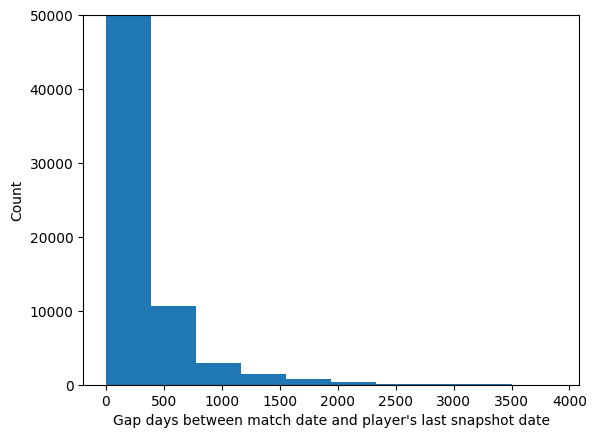

In [216]:
plt.hist(team_match_players.gap_days, bins=10)

plt.xlabel("Gap days between match date and player's last snapshot date")
plt.ylabel("Count")

plt.ylim(0, 50000)

plt.show()

As we can see, most of the players have a **snapshot date** at time of the matches, but there also players with very long absences, which go up to 3500 gap days between player snapshot and match date!

As our decay factor uses a decay half life days of 180 lets see how many of the players exceed these 180 days:

In [217]:
team_match_players[team_match_players.gap_days > 180].shape

(32293, 14)

Well there a lot of players!

You see, if we don't apply these decay factor to these players, we will leave their importance as it was in their last snapshot date!And if we do that, the team strength will not be **realistic**!We just cannot allow that!

So lets define the decay factor:

In [218]:
decay_lambda = np.log(2) / DECAY_HALF_LIFE_DAYS
 
team_match_players["decay_factor"] = np.exp(
    -decay_lambda * team_match_players["gap_days"]
)

And now as we have defined the decay factor lets apply it to the player's importance scores!

In [219]:
team_match_players["importance_score_eff"] = (
    team_match_players["importance_score"] * team_match_players["decay_factor"]
)

In [220]:
team_match_players.importance_score_eff.min(), team_match_players.importance_score_eff.max()

(np.float64(0.0), np.float64(1.0))

Now lets see the distribution of the player's importance scores before and after the decay factor:

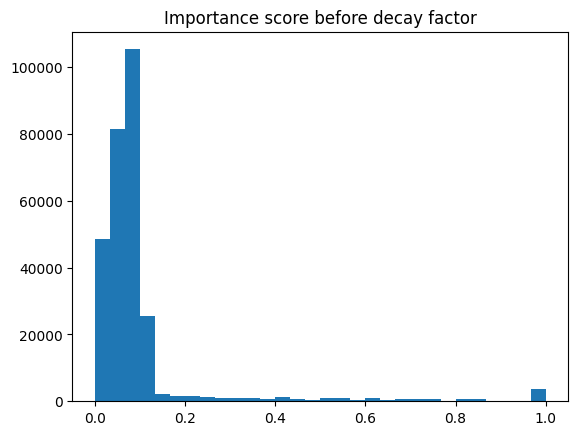

In [221]:
plt.hist(team_match_players.importance_score, bins=30)

plt.title('Importance score before decay factor')
plt.show()

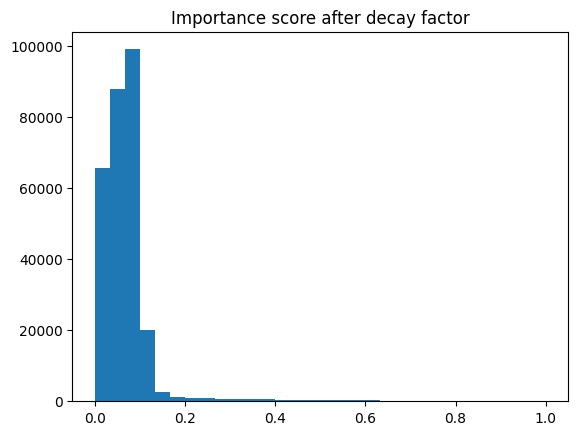

In [222]:
plt.hist(team_match_players.importance_score_eff, bins=30)

plt.title('Importance score after decay factor')
plt.show()

We can see how much much the decay factor has impacted the importances of the players!

Now as we have transformed the importance score of the players, we should **recalculate** some of the features, just because some of them are no longer accurate(because they use the old importances score as base).

I am talking about the key and star player identifiers!They are very important and I cannot leave them using the old importance score!

#### Recalculating the key and star player feature identifies:

In [223]:
team_match_players['importance_score'] = team_match_players['importance_score_eff']

team_match_players = team_match_players.drop(columns='importance_score_eff')

In [224]:
team_match_players["team_rank"] = (
    team_match_players
    .groupby(
        [
            "player_club_id",
            "date"
        ]
    )["importance_score"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [225]:
team_match_players["is_star_player"] = (
    (team_match_players["importance_score"] > 0) &
    (team_match_players["team_rank"] <= 3)
).astype(int)

In [226]:
team_match_players["importance_pct"] = (
    team_match_players
    .groupby(
        [
            "player_club_id",
            "date"
        ]
    )["importance_score"]
    .rank(pct=True)
)

In [227]:
team_match_players["is_key_player"] = (
    team_match_players["importance_pct"] >= 0.65
).astype(int)

In [228]:
team_match_players.is_star_player.value_counts()

is_star_player
0    237926
1     47072
Name: count, dtype: int64

In [229]:
team_match_players.is_key_player.value_counts()

is_key_player
0    174624
1    110374
Name: count, dtype: int64

Now everything is perfect.

Now I will remove some of the useless features from the `team_match_players` dataset:

In [230]:
team_match_players.columns

Index(['game_id', 'date', 'club_id', 'player_id', 'player_club_id',
       'importance_score', 'is_star_player', 'is_key_player', 'position_group',
       'captain_flag', 'expected_starter', 'is_newcomer', 'snapshot_date',
       'gap_days', 'decay_factor', 'team_rank', 'importance_pct'],
      dtype='str')

In [231]:
team_match_players = team_match_players.drop(columns=['gap_days', 'decay_factor', 'team_rank', 'importance_pct'])

In [232]:
team_match_players.columns

Index(['game_id', 'date', 'club_id', 'player_id', 'player_club_id',
       'importance_score', 'is_star_player', 'is_key_player', 'position_group',
       'captain_flag', 'expected_starter', 'is_newcomer', 'snapshot_date'],
      dtype='str')

---

### Handling the player's injuries:

Now something which is very important, is to account for the players injuries!In order to really create the most accurate and reliable team's strength we cannot leave injured players during the matches.

What we have done by now is that we collected all of the available, transfered and valid players for each of the teams before the matches.We defined their importances as also the team strength before the matches.So far so good.Something we didn't do is to check which players were injured during these matches!

So lets do this now!I will use the players injuries dataset, which in the very beggining of this notebook was explored and cleaned!

I will first get the needed info from the injuries dataset, then I will merge the injuries with the player matches and for each of the players I will check if his availability throughout the matches.

In [233]:
injuries_interim_df.columns

Index(['player_id', 'season_name', 'injury_reason', 'from_date', 'end_date',
       'days_missed', 'games_missed'],
      dtype='str')

In [234]:
injury_active = injuries_interim_df[["player_id", "from_date", "end_date"]].copy()

In [235]:
tmp = team_match_players[["game_id", "club_id", "player_id", "date"]].merge(
    injury_active, on="player_id", how="left"
)

Now I will create an **in_window** identifier to check if a player injury has started before the date of the matche and has ended(or not) after the date of the match: 

In [236]:
tmp["_in_window"] = (tmp["date"] >= tmp["from_date"]) & (
    tmp["end_date"].isna() | (tmp["date"] <= tmp["end_date"])
)

Now I will group the data by game, club and player and check if there has been an injury for the player at the time of the match!

In [237]:
is_injured_series = (
    tmp.groupby(["game_id", "club_id", "player_id"])["_in_window"]
    .any()
    .rename("is_injured")
    .reset_index()
)

In [238]:
is_injured_series[is_injured_series.is_injured].shape, is_injured_series[~is_injured_series.is_injured].shape, 

((24057, 4), (260941, 4))

Now I will merge the result of this with the matches of the players:

In [239]:
team_match_players = team_match_players.merge(
    is_injured_series, on=["game_id", "club_id", "player_id"], how="left"
)

In [240]:
team_match_players["is_injured"] = (
    team_match_players["is_injured"].astype(int)
)

> Now with this injury addition, we already know if which players were available before the matches and we can create the right team's squads before the matches and define the real team strength using only what was available during the matches!

---

Now before proceeding with the implementation of the final features, I will create two player flags which later will be used in the creation of the final features.

These flags will be the top-1 and top-3 player flag, which will identify if a player is **top 1 top 3** in the team's squad based in his importance!

Lets create these features:
#### Creating top 1 / top 3 player flags:

In [241]:
team_match_players["importance_rank"] = (
    team_match_players
    .groupby(
        [
            "game_id", "club_id"
        ]
    )["importance_score"]
    .rank(method="first", ascending=False)
)

In [242]:
team_match_players["is_top1"] = (team_match_players["importance_rank"] == 1).astype(int)
team_match_players["is_top3"] = (team_match_players["importance_rank"] <= 3).astype(int)

Ok now everything is perfect.

#### What we did by now:
By this moment we **defined the importances of the players** using their impact over the games.We collected all of the players that were part of the teams at time of their matches, as the **full team squad**.We defined the team strength using the importance of the players and identified which of the team's players were injured during the matches.

After all this, I think we are ready to proceed with the creation of the **long awaited features** that all of the work was all about:

---
## Creating the final features:
- missing_players_count
- missing_key_players_count
- missing_star_players_count
- missing_importance_sum - The sum of the missing players importance score
- missing_importance_ratio - The division of the missing players importance score with the total team squad importance
- missing_defenders
- missing_midfielders
- missing_forwards
- starting_goalkeeper_missing

In order to create all of these features I will group the data by **game_id and club_id**, as the target outcome is to get all these features at match level for each of the teams!

Lets begin with the creation of the features:

First lets check if there are any duplicates: ['game_id', 'club_id', 'player_id'] - There should not be more than one unique player in the same match for the same team:

In [243]:
team_match_players.duplicated(subset=['game_id', 'club_id', 'player_id']).any()

np.False_

In [244]:
g = team_match_players.groupby(["game_id", "club_id"])

#### Defining the team total and expected importance:

In [245]:
team_total_importance = g["importance_score"].sum().rename("total_imp")
 
expected_total_importance = (
    team_match_players[team_match_players["expected_starter"] == 1]
    .groupby(["game_id", "club_id"])["importance_score"].sum()
    .rename("exp_total_imp")
)

#### Defining the missing players features:
- missing_players_count
- missing_key_players_count
- missing_star_players_count
- missing_importance_sum

In [246]:
# Getting the injured players:
inj = team_match_players[team_match_players["is_injured"] == 1]
g_inj = inj.groupby(["game_id", "club_id"])

In [247]:
missing_players_count = g_inj["player_id"].count().rename("missing_players_count")
missing_key_players_count = g_inj["is_key_player"].sum().rename("missing_key_players_count")
missing_star_players_count = g_inj["is_star_player"].sum().rename("missing_star_players_count")
missing_importance_sum = g_inj["importance_score"].sum().rename("missing_importance_sum")

#### Defining the missing players features based on the player's position group:
- missing_defenders
- missing_midfielders
- missing_forwards
- starting_goalkeeper_missing
- missing_captain

In [248]:
missing_defenders = (inj["position_group"] == "DEF").groupby([inj["game_id"], inj["club_id"]]).sum().rename("missing_defenders")
missing_midfielders = (inj["position_group"] == "MID").groupby([inj["game_id"], inj["club_id"]]).sum().rename("missing_midfielders")
missing_forwards = (inj["position_group"] == "FWD").groupby([inj["game_id"], inj["club_id"]]).sum().rename("missing_forwards")

# A starting goalkeeper is missing if the goalkeeper is expected starter for the game!
starting_goalkeeper_missing = (
    inj[(inj["position_group"] == "GK") & (inj["expected_starter"] == 1)]
    .groupby(["game_id", "club_id"])["player_id"].count().gt(0).astype(int)
    .rename("starting_goalkeeper_missing")
)

# A captain is missing if player is with captain flag for the game!
missing_captain = (
    inj[inj["captain_flag"] == 1]
    .groupby(["game_id", "club_id"])["player_id"].count().gt(0).astype(int)
    .rename("missing_captain")
)

#### Defining the missing team strength:
- missing_expected_starter_strength
- missing_gk_strength
- missing_def_strength
- missing_mid_strength
- missing_fwd_strength

In [249]:
missing_expected_starter_strength = (
    inj[inj["expected_starter"] == 1]
    .groupby(["game_id", "club_id"])["importance_score"].sum()
    .rename("missing_expected_starter_strength")
)

missing_gk_strength = (inj[inj["position_group"] == "GK"] .groupby(["game_id", "club_id"])["importance_score"].sum().rename("missing_gk_strength"))
missing_def_strength = (inj[inj["position_group"] == "DEF"].groupby(["game_id", "club_id"])["importance_score"].sum().rename("missing_def_strength"))
missing_mid_strength = (inj[inj["position_group"] == "MID"].groupby(["game_id", "club_id"])["importance_score"].sum().rename("missing_mid_strength"))
missing_fwd_strength = (inj[inj["position_group"] == "FWD"].groupby(["game_id", "club_id"])["importance_score"].sum().rename("missing_fwd_strength"))

#### Defining missing top 1/ top 3 missing players:
- missing_top1_player
- missing_top3_player

In [250]:
missing_top1_player = (
    inj[inj["is_top1"] == 1]
    .groupby(["game_id", "club_id"])["player_id"].count().gt(0).astype(int)
    .rename("missing_top1_player")
)

missing_top3_player = (
    inj[inj["is_top3"] == 1]
    .groupby(["game_id", "club_id"])["player_id"].count().gt(0).astype(int)
    .rename("missing_top3_player")
)

#### Defining available strength features:
- available_strength
- exp_available_strength

In [251]:
avail = team_match_players[team_match_players["is_injured"] == 0]
 
available_strength = (
    avail.groupby(["game_id", "club_id"])["importance_score"].sum()
    .rename("available_strength")
)

expected_available_importance = (
    avail[avail["expected_starter"] == 1]
    .groupby(["game_id", "club_id"])["importance_score"].sum()
    .rename("exp_available_strength")
)

---

Now lets merge all these features with the team's matches:

### Merging the final features with the team's matches:

In [252]:
# Getting only the unqiue matches:
base_idx = (
    team_match_players[["game_id", "club_id"]]
    .drop_duplicates()
    .set_index(["game_id", "club_id"])
)

In [253]:
# All of the newly created features: 
series_list = [
    missing_players_count, missing_key_players_count, missing_star_players_count,
    missing_importance_sum, missing_defenders, missing_midfielders, missing_forwards,
    starting_goalkeeper_missing, missing_captain, missing_top1_player,
    missing_top3_player, available_strength, missing_expected_starter_strength,
    missing_gk_strength, missing_def_strength, missing_mid_strength, missing_fwd_strength,
    team_total_importance, expected_total_importance, expected_available_importance,
]

In [254]:
team_features = base_idx.copy()

# Adding the features into the team's matches:
for s in series_list:
    team_features = team_features.join(s, how="left")
 
team_features = team_features.reset_index()

In [255]:
team_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 18573 entries, 0 to 18572
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   game_id                            18573 non-null  int32  
 1   club_id                            18573 non-null  int32  
 2   missing_players_count              9763 non-null   float64
 3   missing_key_players_count          9763 non-null   float64
 4   missing_star_players_count         9763 non-null   float64
 5   missing_importance_sum             9763 non-null   float64
 6   missing_defenders                  9763 non-null   float64
 7   missing_midfielders                9763 non-null   float64
 8   missing_forwards                   9763 non-null   float64
 9   starting_goalkeeper_missing        1327 non-null   float64
 10  missing_captain                    1324 non-null   float64
 11  missing_top1_player                975 non-null    float64
 12  m

#### Imputing the missing values:

I will fill in all of the missing values with zeros, just because there is no other value to be put, and if the specific features has no value for the specific match, it is expected the value to be zero!

In [256]:
zero_fill_cols = [
    "missing_players_count", "missing_key_players_count", "missing_star_players_count",
    "missing_importance_sum", "missing_defenders", "missing_midfielders", "missing_forwards",
    "starting_goalkeeper_missing", "missing_captain", "missing_top1_player", 
    "missing_top3_player", "missing_expected_starter_strength",
    "missing_gk_strength", "missing_def_strength", "missing_mid_strength", "missing_fwd_strength",
    "available_strength", "exp_total_imp", "exp_available_strength"
]

team_features[zero_fill_cols] = team_features[zero_fill_cols].fillna(0)

In [257]:
team_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 18573 entries, 0 to 18572
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   game_id                            18573 non-null  int32  
 1   club_id                            18573 non-null  int32  
 2   missing_players_count              18573 non-null  float64
 3   missing_key_players_count          18573 non-null  float64
 4   missing_star_players_count         18573 non-null  float64
 5   missing_importance_sum             18573 non-null  float64
 6   missing_defenders                  18573 non-null  float64
 7   missing_midfielders                18573 non-null  float64
 8   missing_forwards                   18573 non-null  float64
 9   starting_goalkeeper_missing        18573 non-null  float64
 10  missing_captain                    18573 non-null  float64
 11  missing_top1_player                18573 non-null  float64
 12  m

### Creating additional features
- missing_importance_ratio - missing_importance_sum / total_importance
- squad_stability - exp_available_strength / exp_total_imp

In [258]:
team_features["missing_importance_ratio"] = np.where(
    team_features["total_imp"] > 0,
    team_features["missing_importance_sum"] / team_features["total_imp"],
    0.0,
)
team_features["squad_stability"] = np.where(
    team_features["exp_total_imp"] > 0,
    team_features["exp_available_strength"] / team_features["exp_total_imp"],
    1.0,
)

#### Removing helping features:

In [259]:
team_features = team_features.drop(
    columns=["total_imp", "exp_total_imp", "exp_available_strength"], errors="ignore"
)

### Final feature cols:

In [260]:
team_features.columns

Index(['game_id', 'club_id', 'missing_players_count',
       'missing_key_players_count', 'missing_star_players_count',
       'missing_importance_sum', 'missing_defenders', 'missing_midfielders',
       'missing_forwards', 'starting_goalkeeper_missing', 'missing_captain',
       'missing_top1_player', 'missing_top3_player', 'available_strength',
       'missing_expected_starter_strength', 'missing_gk_strength',
       'missing_def_strength', 'missing_mid_strength', 'missing_fwd_strength',
       'missing_importance_ratio', 'squad_stability'],
      dtype='str')

In [261]:
# I will need to create this columns list because later I will use it when creating the home and away team features:
FEATURE_COLS = [
    "missing_players_count", "missing_key_players_count", "missing_star_players_count",
    "missing_importance_sum", "missing_importance_ratio",
    "missing_defenders", "missing_midfielders", "missing_forwards",
    "starting_goalkeeper_missing", "missing_captain", "missing_top1_player",
    "missing_top3_player", "available_strength", "missing_expected_starter_strength",
    "missing_gk_strength", "missing_def_strength", "missing_mid_strength",
    "missing_fwd_strength", "squad_stability",
]

#### Pivot to Home / Away matches and merge:

In [262]:
home_features = (
    team_features
    .rename(columns={"club_id": "home_club_id"})
    .rename(columns={c: f"home_{c}" for c in FEATURE_COLS})
)

away_features = (
    team_features
    .rename(columns={"club_id": "away_club_id"})
    .rename(columns={c: f"away_{c}" for c in FEATURE_COLS})
)

## Merging the home and away team features with the `matches_interim_df`:

In [263]:
matches_interim_df = (
    matches_interim_df
    .merge(home_features, on=["game_id", "home_club_id"], how="left")
    .merge(away_features, on=["game_id", "away_club_id"], how="left")
)

In [264]:
matches_interim_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13788 entries, 0 to 13787
Data columns (total 59 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   game_id                                 13788 non-null  int32         
 1   competition_id                          13788 non-null  category      
 2   season                                  13788 non-null  category      
 3   round                                   13788 non-null  category      
 4   date                                    13788 non-null  datetime64[us]
 5   home_club_id                            13788 non-null  int32         
 6   away_club_id                            13788 non-null  int32         
 7   home_club_goals                         13788 non-null  int8          
 8   away_club_goals                         13788 non-null  int8          
 9   home_club_position                      4180 non-null   Int8 

I want to specifically see the features info of the LaLiga matches:

In [265]:
matches_interim_df[matches_interim_df.competition_id == 'ES1'].info()

<class 'pandas.DataFrame'>
Index: 4180 entries, 1 to 12937
Data columns (total 59 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   game_id                                 4180 non-null   int32         
 1   competition_id                          4180 non-null   category      
 2   season                                  4180 non-null   category      
 3   round                                   4180 non-null   category      
 4   date                                    4180 non-null   datetime64[us]
 5   home_club_id                            4180 non-null   int32         
 6   away_club_id                            4180 non-null   int32         
 7   home_club_goals                         4180 non-null   int8          
 8   away_club_goals                         4180 non-null   int8          
 9   home_club_position                      4180 non-null   Int8       

Overall everything seems to be good, with one exception - There are still some missing values, but they are very few, so I don't think this will be a problem!I will handle them in the final data preparation when all of the datasets are combined!

However, what you see is the final result of the matches_interim_df with the addition of the new features.

---

Now finally lets save this verion of the `matches_interim_df` dataset:
### Saving the data:

In [266]:
PROJECT_ROOT = Path().resolve().parent.parent

file_path = PROJECT_ROOT / TRANSFERMARKT_DATA_INTERIM_PATH
file_path.mkdir(parents=True, exist_ok=True)

In [267]:
file_path = PROJECT_ROOT / TRANSFERMARKT_DATA_INTERIM_PATH / 'interim_matches_v2.parquet'

save_data(data=matches_interim_df, file_path=file_path)

The file has already been created and it contains the exact data as the original dataset!


---

> ##### This is not the end of the transfermarkt data cleaning.There are still some other features that need to be created and these features are about the match importance and team-presure of the teams!However, as this notebook became too big, I will proceed with the creation of the new features into a new notebool(`transfermarkt_data_cleaning_part_3`)

---